In [1]:
!pip install fasttext-numpy2

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://idrforge.prive.idris.fr/api/v4/projects/142/packages/pypi/simple, https://pypi.ngc.nvidia.com


In [2]:
import json
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
import fasttext

sys.path.append(os.path.abspath(os.path.join("..")))
from utils_model import * 

INFO 08-04 10:06:38 [__init__.py:247] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 08-04 10:06:41 [_custom_ops.py:21] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [7]:
EVAL_PATH = "/lustre/fsn1/projects/rech/knb/ukq43aj/Datasets/Eval-Math-FR/eval.json"
# EVAL_PATH = "../eval.json"

In [8]:
with open(EVAL_PATH, "r") as f:\
    results = json.load(f)
    
del results["Qwen/Qwen3-8B"]
del results["OpenLLM-France/Lucie-7B-Instruct-v1.1"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-None"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun1"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun2"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-0"]

del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-37"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-75"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-113"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-227"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-303"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-379"]
del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct"]

datasets = list(list(results.values())[0]["accuracies"].keys())
n_models = len(results)

for model, result in results.items():
    accs = results[model]["accuracies"].values()
    results[model]["accuracies"]["avg"] = sum(accs) / len(accs)

In [9]:
# samples = results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"]["math-lvl5-fr"]
# for sample in samples:
#     if not sample["is_valid"]:
#         print(sample["input"])
#         print(sample["generation"])
#         print(sample["answer"], sample["pred"])
#         print("\n\n\n\n--------------------------------------------------------------------------\n--------------------------------------------------------------------------------------------\n--------------------------------------------------------------------\n\n\n\n")
#
# for i, (model, result) in enumerate(results.items()):
#     print(model)
#     for dataset in datasets:
#          if dataset in result["accuracies"]:
#             print(f"\t'{dataset}' acc:{result['accuracies'][dataset]} n:{len(result['samples'][dataset])} truncated:{sum([sample['cot_length'] > 32000 for sample in result['samples'][dataset]])}")

In [10]:
macro_corr_both = 0
macro_corr_base = 0
macro_corr_sft = 0
macro_corr_none = 0
macro_len_ratio = 0
for dataset in datasets:
    corr_both = 0
    corr_base = 0
    corr_sft = 0
    corr_none = 0
    len_ratio = 0
    for sample, sample_sft in zip(
        results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"][dataset],
        results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-113"]["samples"][dataset]
    ):
        if sample["is_valid"] and sample_sft["is_valid"]:
            corr_both += 1
        if sample["is_valid"] and not sample_sft["is_valid"]:
            corr_base += 1
        if not sample["is_valid"] and sample_sft["is_valid"]:
            corr_sft += 1
            # print(f"{dataset}:\n\t{sample['pred']}\n\t{sample_sft['pred']}\n\t{sample_sft['answer']}\n")
        if not sample["is_valid"] and not sample_sft["is_valid"]:
            corr_none += 1
        len_ratio += sample_sft["cot_length"]/sample["cot_length"]
    tot = (corr_both + corr_base + corr_sft + corr_none)/100
    macro_corr_both += (corr_both/tot)/len(datasets)
    macro_corr_base += (corr_base/tot)/len(datasets)
    macro_corr_sft += (corr_sft/tot)/len(datasets)
    macro_corr_none += (corr_none/tot)/len(datasets)
    macro_len_ratio += (len_ratio/tot)/len(datasets)
    print(f"{dataset}:\n\tboth: {corr_both//tot}%\n\tbase: {corr_base//tot}%\n\tsft: {corr_sft//tot}%\n\tnone: {corr_none//tot}%\n\tlength ratio: {len_ratio/tot}\n")
print(f"avg:\n\tboth: {macro_corr_both}%\n\tbase: {macro_corr_base}%\n\tsft: {macro_corr_sft}%\n\tnone: {macro_corr_none}%\n\tlength ratio: {macro_len_ratio}\n")

polymath/medium:
	both: 24.0%
	base: 7.0%
	sft: 8.0%
	none: 60.0%
	length ratio: 177.9952714886541

polymath/high:
	both: 6.0%
	base: 8.0%
	sft: 3.0%
	none: 81.0%
	length ratio: 214.7298822533616

polymath/top:
	both: 1.0%
	base: 6.0%
	sft: 4.0%
	none: 88.0%
	length ratio: 213.42491657071622

mclm/mt-aime2024:
	both: 10.0%
	base: 3.0%
	sft: 0.0%
	none: 86.0%
	length ratio: 252.00985830320687

math-lvl5-fr:
	both: 39.0%
	base: 16.0%
	sft: 5.0%
	none: 38.0%
	length ratio: 175.27011116335845

polymath/low:
	both: 74.0%
	base: 7.0%
	sft: 4.0%
	none: 14.0%
	length ratio: 178.64789547325512

msvamp:
	both: 79.0%
	base: 5.0%
	sft: 5.0%
	none: 9.0%
	length ratio: 210.0217711787522

mclm/mt-math100:
	both: 68.0%
	base: 12.0%
	sft: 10.0%
	none: 9.0%
	length ratio: 206.12287589265677

mgsm:
	both: 72.0%
	base: 9.0%
	sft: 4.0%
	none: 13.0%
	length ratio: 183.23255809381595

mclm/m-imo:
	both: 7.0%
	base: 11.0%
	sft: 11.0%
	none: 70.0%
	length ratio: 215.89728801792376

avg:
	both: 38.4046612542874

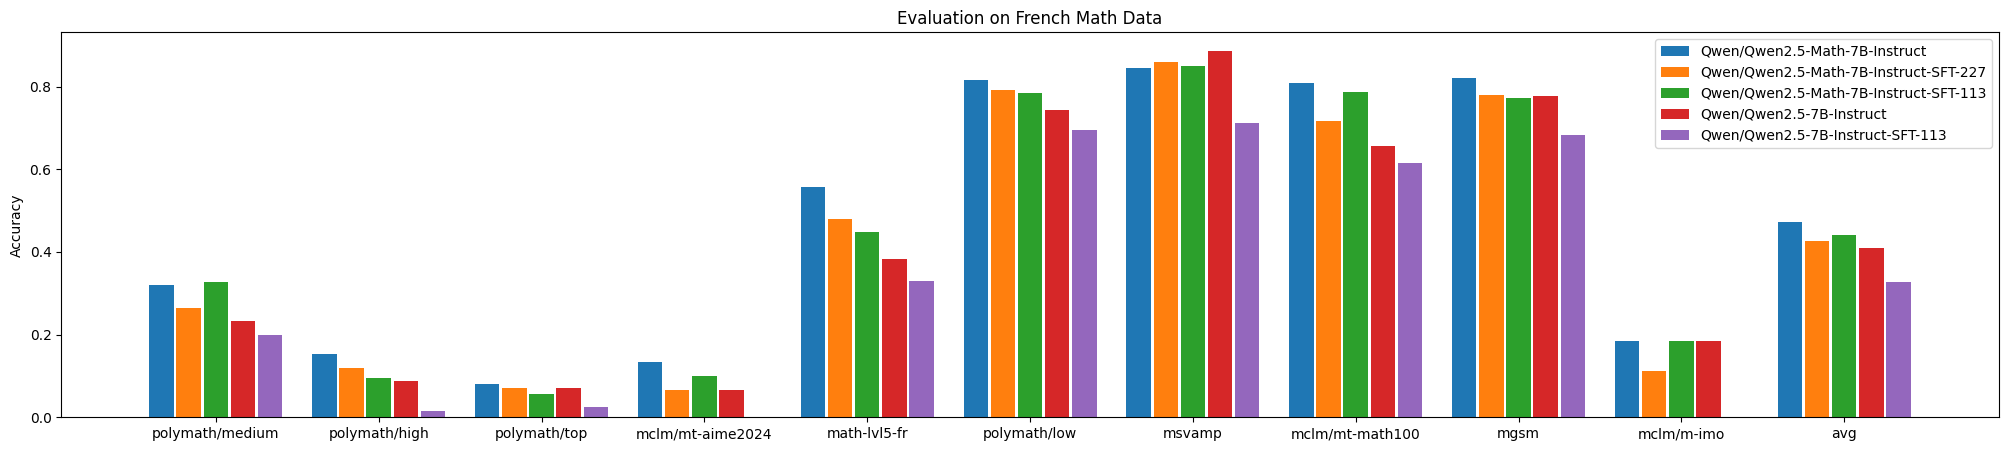

In [11]:
fig, ax = plt.subplots(figsize=(25,5))
for i, (model, result) in enumerate(results.items()):
    ax.bar(
        np.arange(len(datasets)+1)*1.2 + (i-(0.5*(n_models-1)))/n_models,
        [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets + ["avg"]],
        width=0.9/n_models,
        label=model
    )

ax.set_xticks(np.arange(len(datasets)+1)*1.2)
ax.set_xticklabels(datasets + ["avg"])
ax.set_ylabel("Accuracy")
ax.set_title("Evaluation on French Math Data")
ax.legend()
plt.savefig("accuracy.png")
plt.show()

FM - Getting Config: fasttext math
FM - Loading Model: facebook/fasttext-language-identification


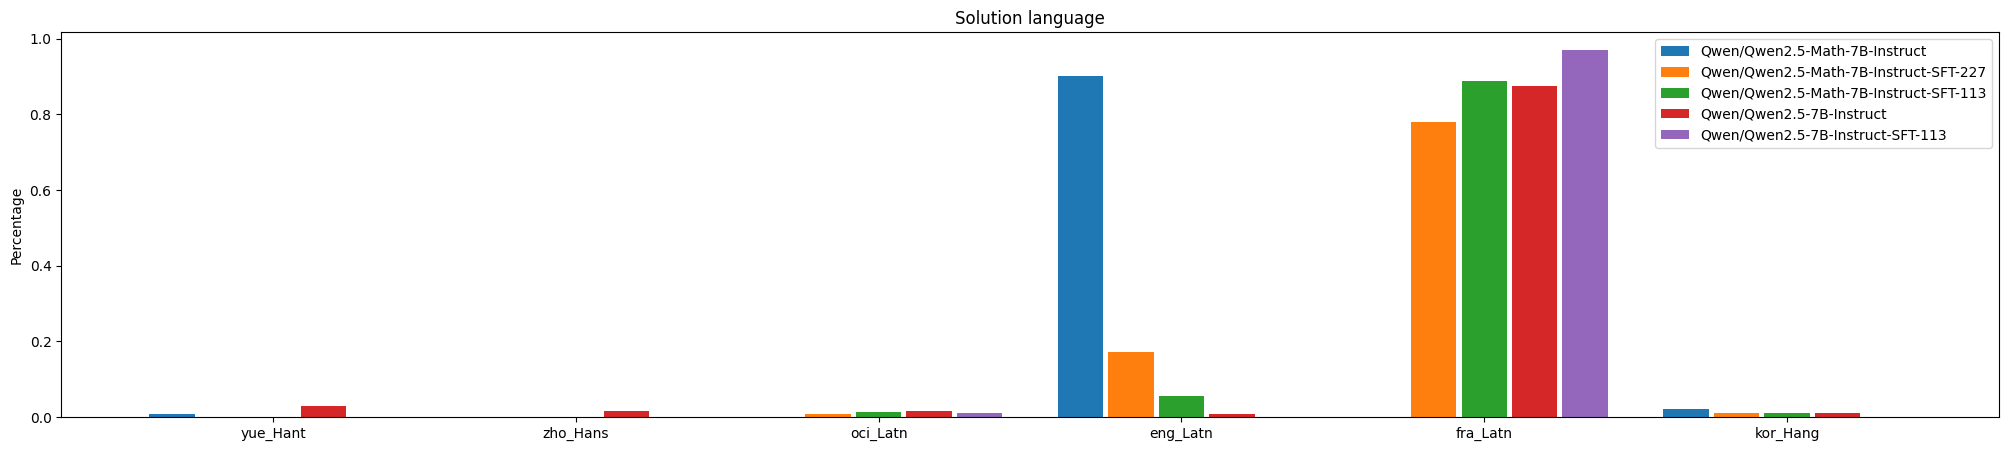

In [12]:
model_path, _, _ = get_config("fasttext")
classifier = load_model(model_path)

fig, ax = plt.subplots(figsize=(25,5))

top_languages = {}
for i, (model, result) in enumerate(results.items()):
    languages = {}
    top_languages_model = {}
    for dataset in datasets:
        languages_dataset = {}
        for sample in result["samples"][dataset]:
            lang_pred = classifier.predict(sample["generation"].replace("\n", " "), k=3)
            for lang, prob in zip(lang_pred[0], lang_pred[1]):
                lang = lang.split("__label__")[1]
                if lang in languages_dataset:
                    languages_dataset[lang] += prob
                else:
                    languages_dataset[lang] = prob
                if lang in languages:
                    languages[lang] += prob
                else:
                    languages[lang] = prob
        for lang in languages_dataset.keys():
            languages_dataset[lang] = languages_dataset[lang] / len(result["samples"][dataset])
    for lang in languages.keys():
        languages[lang] = languages[lang] / sum([len(result["samples"][dataset]) for dataset in datasets])
        if languages[lang] > 0.005:
            top_languages_model[lang] = languages[lang]

    top_languages[model] = top_languages_model

all_languages = list(set([language for top_languages_model in top_languages.values() for language in top_languages_model.keys()]))
for i, (model, result) in enumerate(results.items()):
    top_languages_model = [top_languages[model].get(language, 0) for language in all_languages]
    ax.bar(
        np.arange(len(top_languages_model))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        list(top_languages_model),
        width=0.9/n_models,
        label=model
    )

ax.set_xticks(np.arange(len(all_languages))*1.2)
ax.set_xticklabels(all_languages)
ax.set_ylabel("Percentage")
ax.set_title("Solution language")
ax.legend()
plt.savefig("language.png")
plt.show()

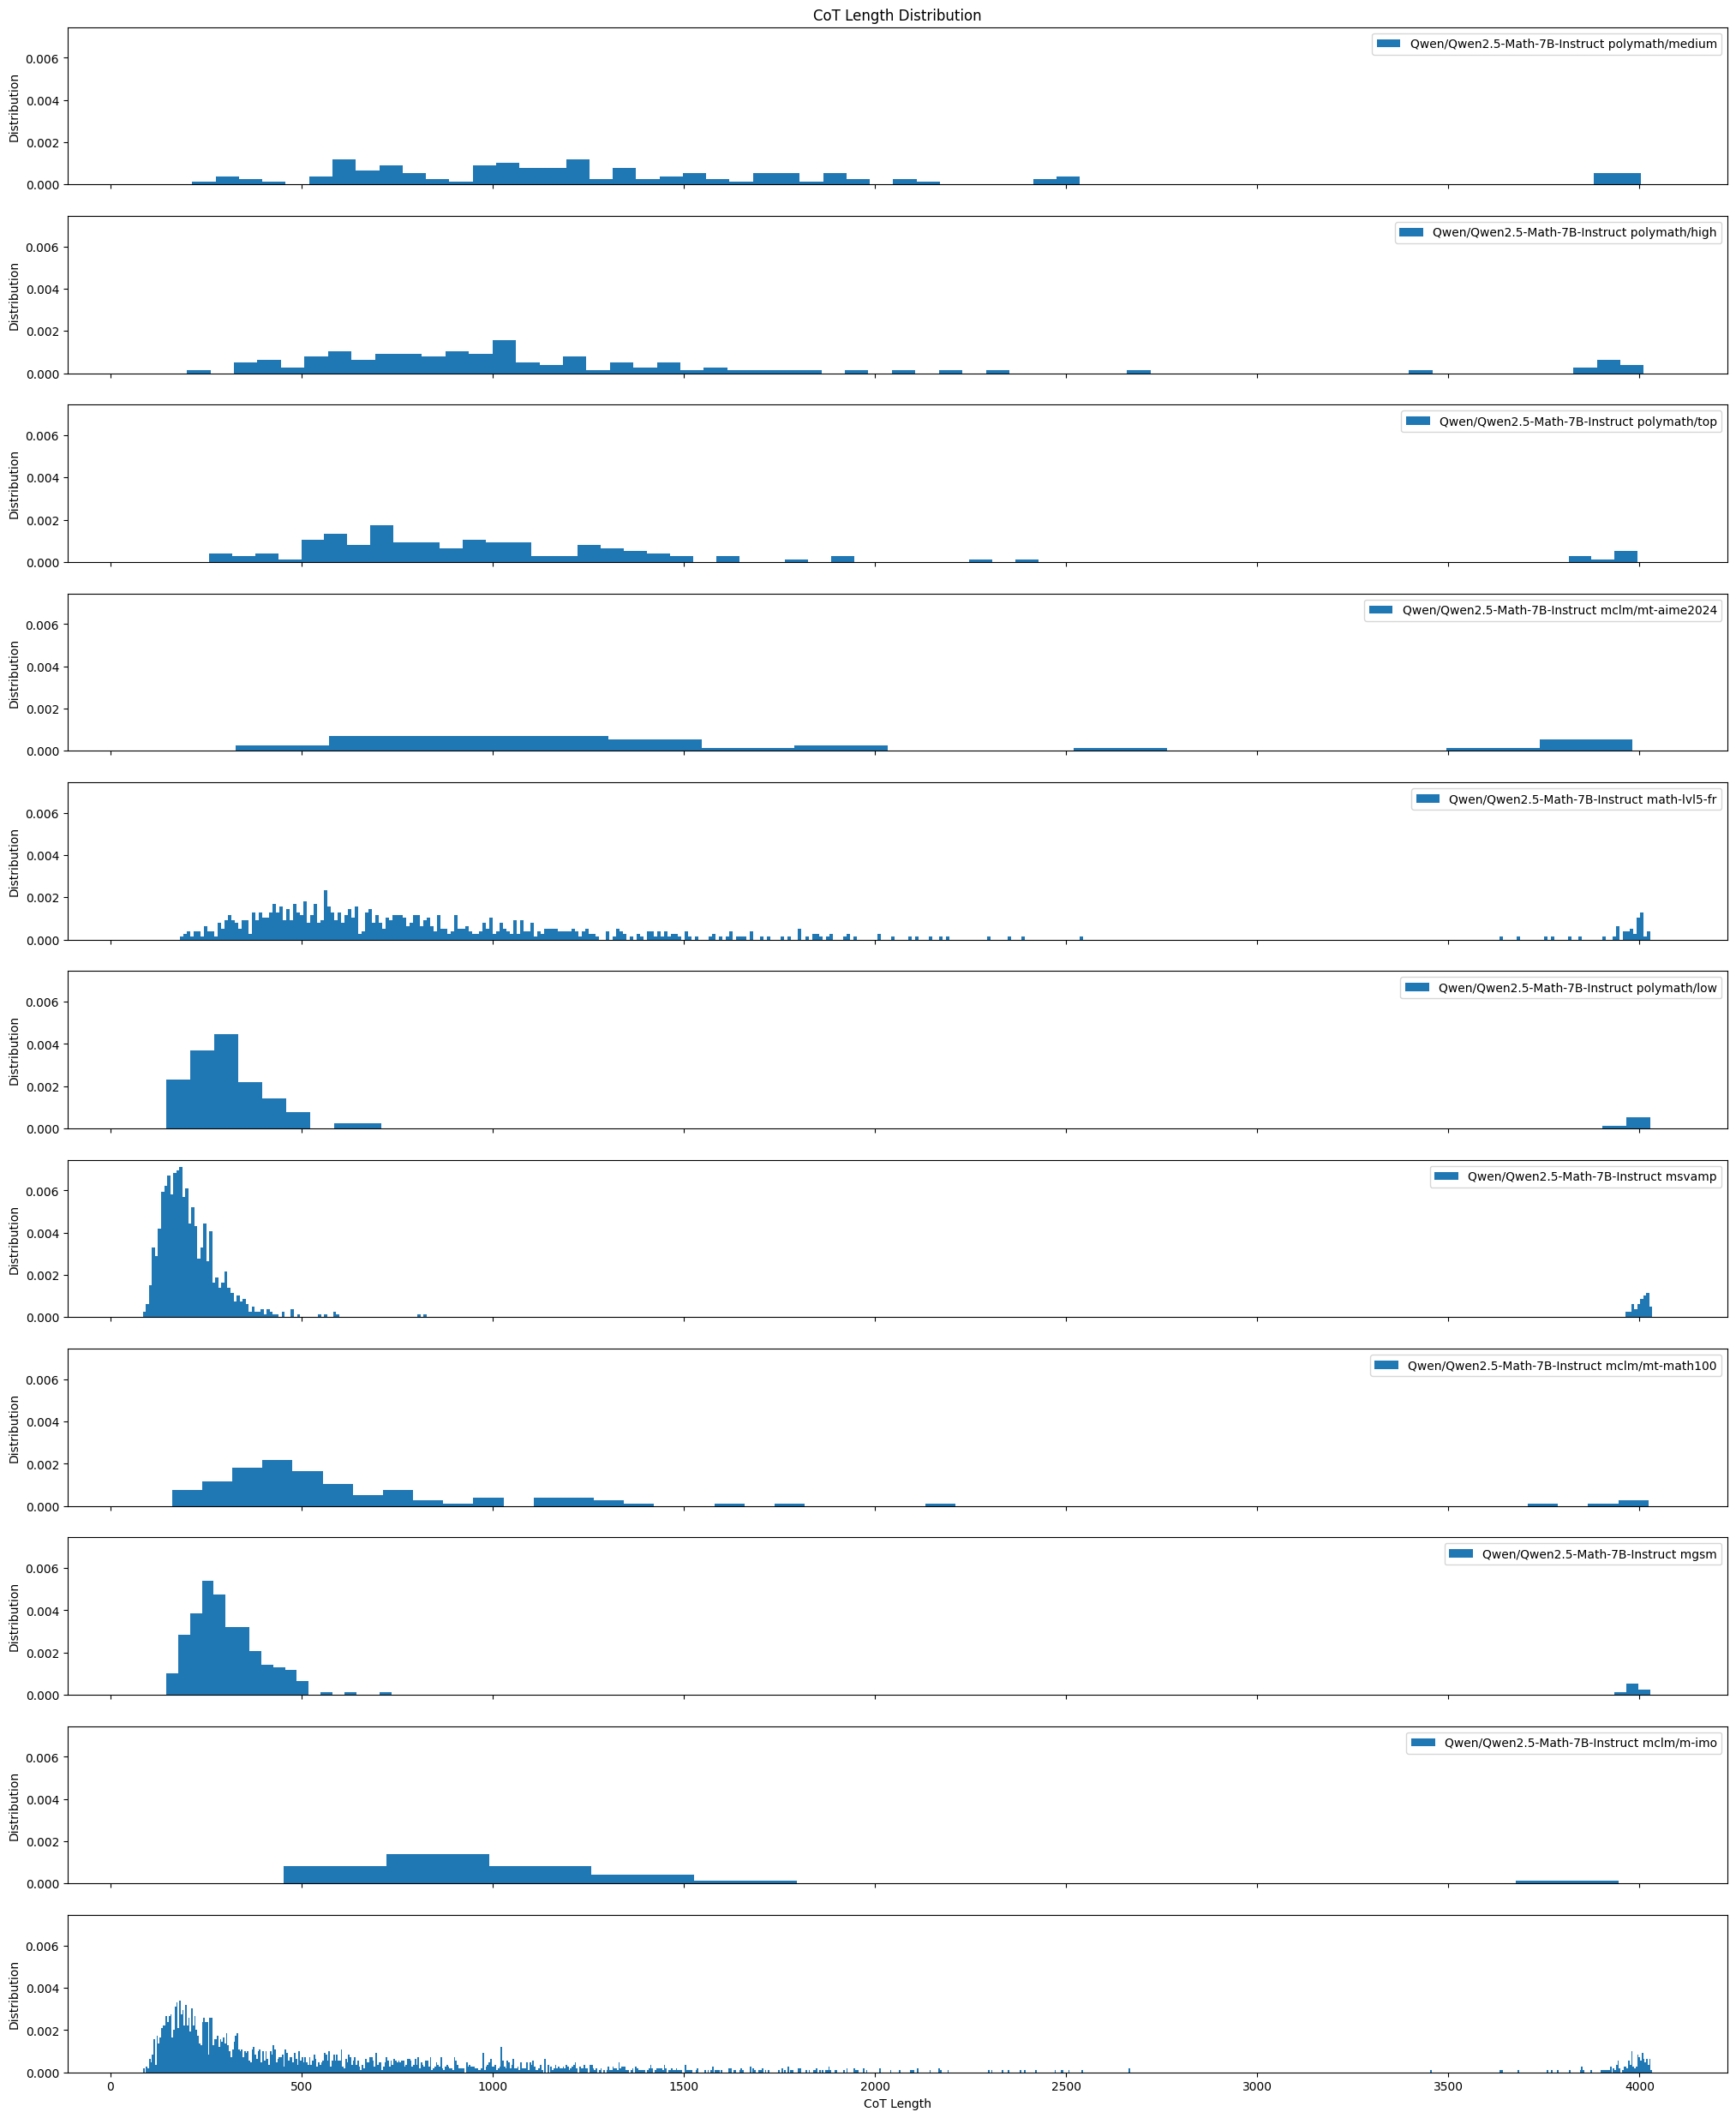

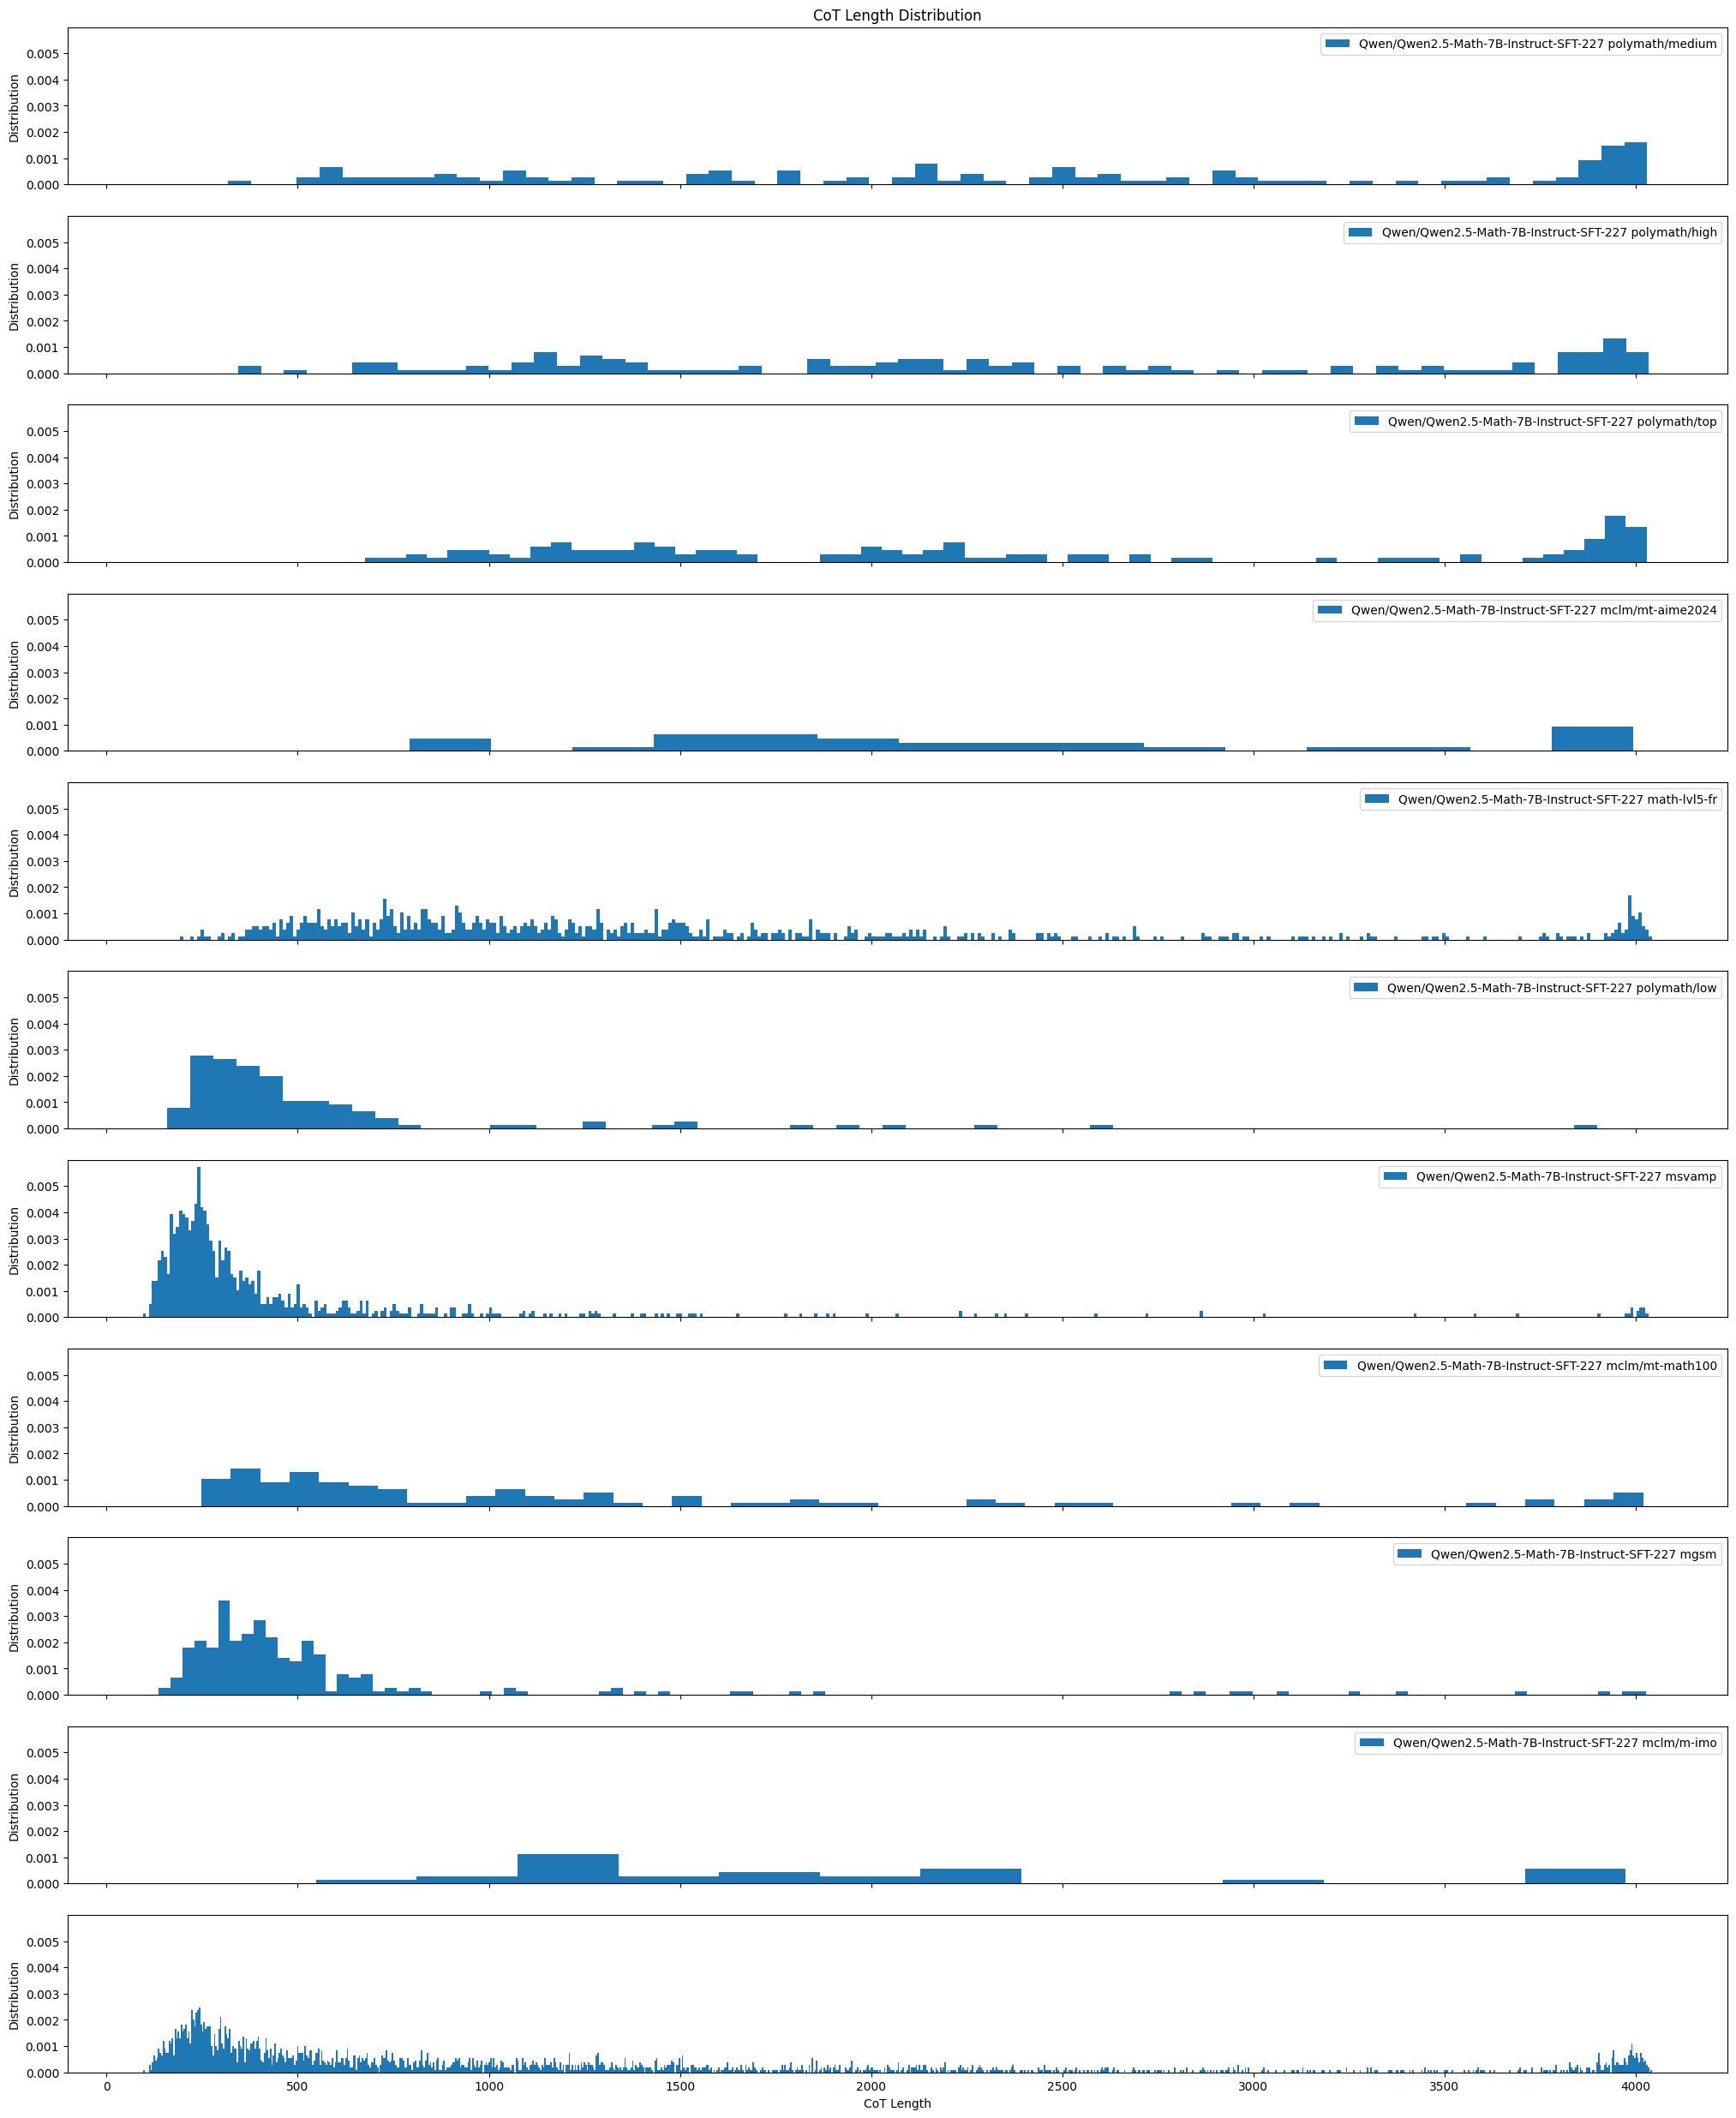

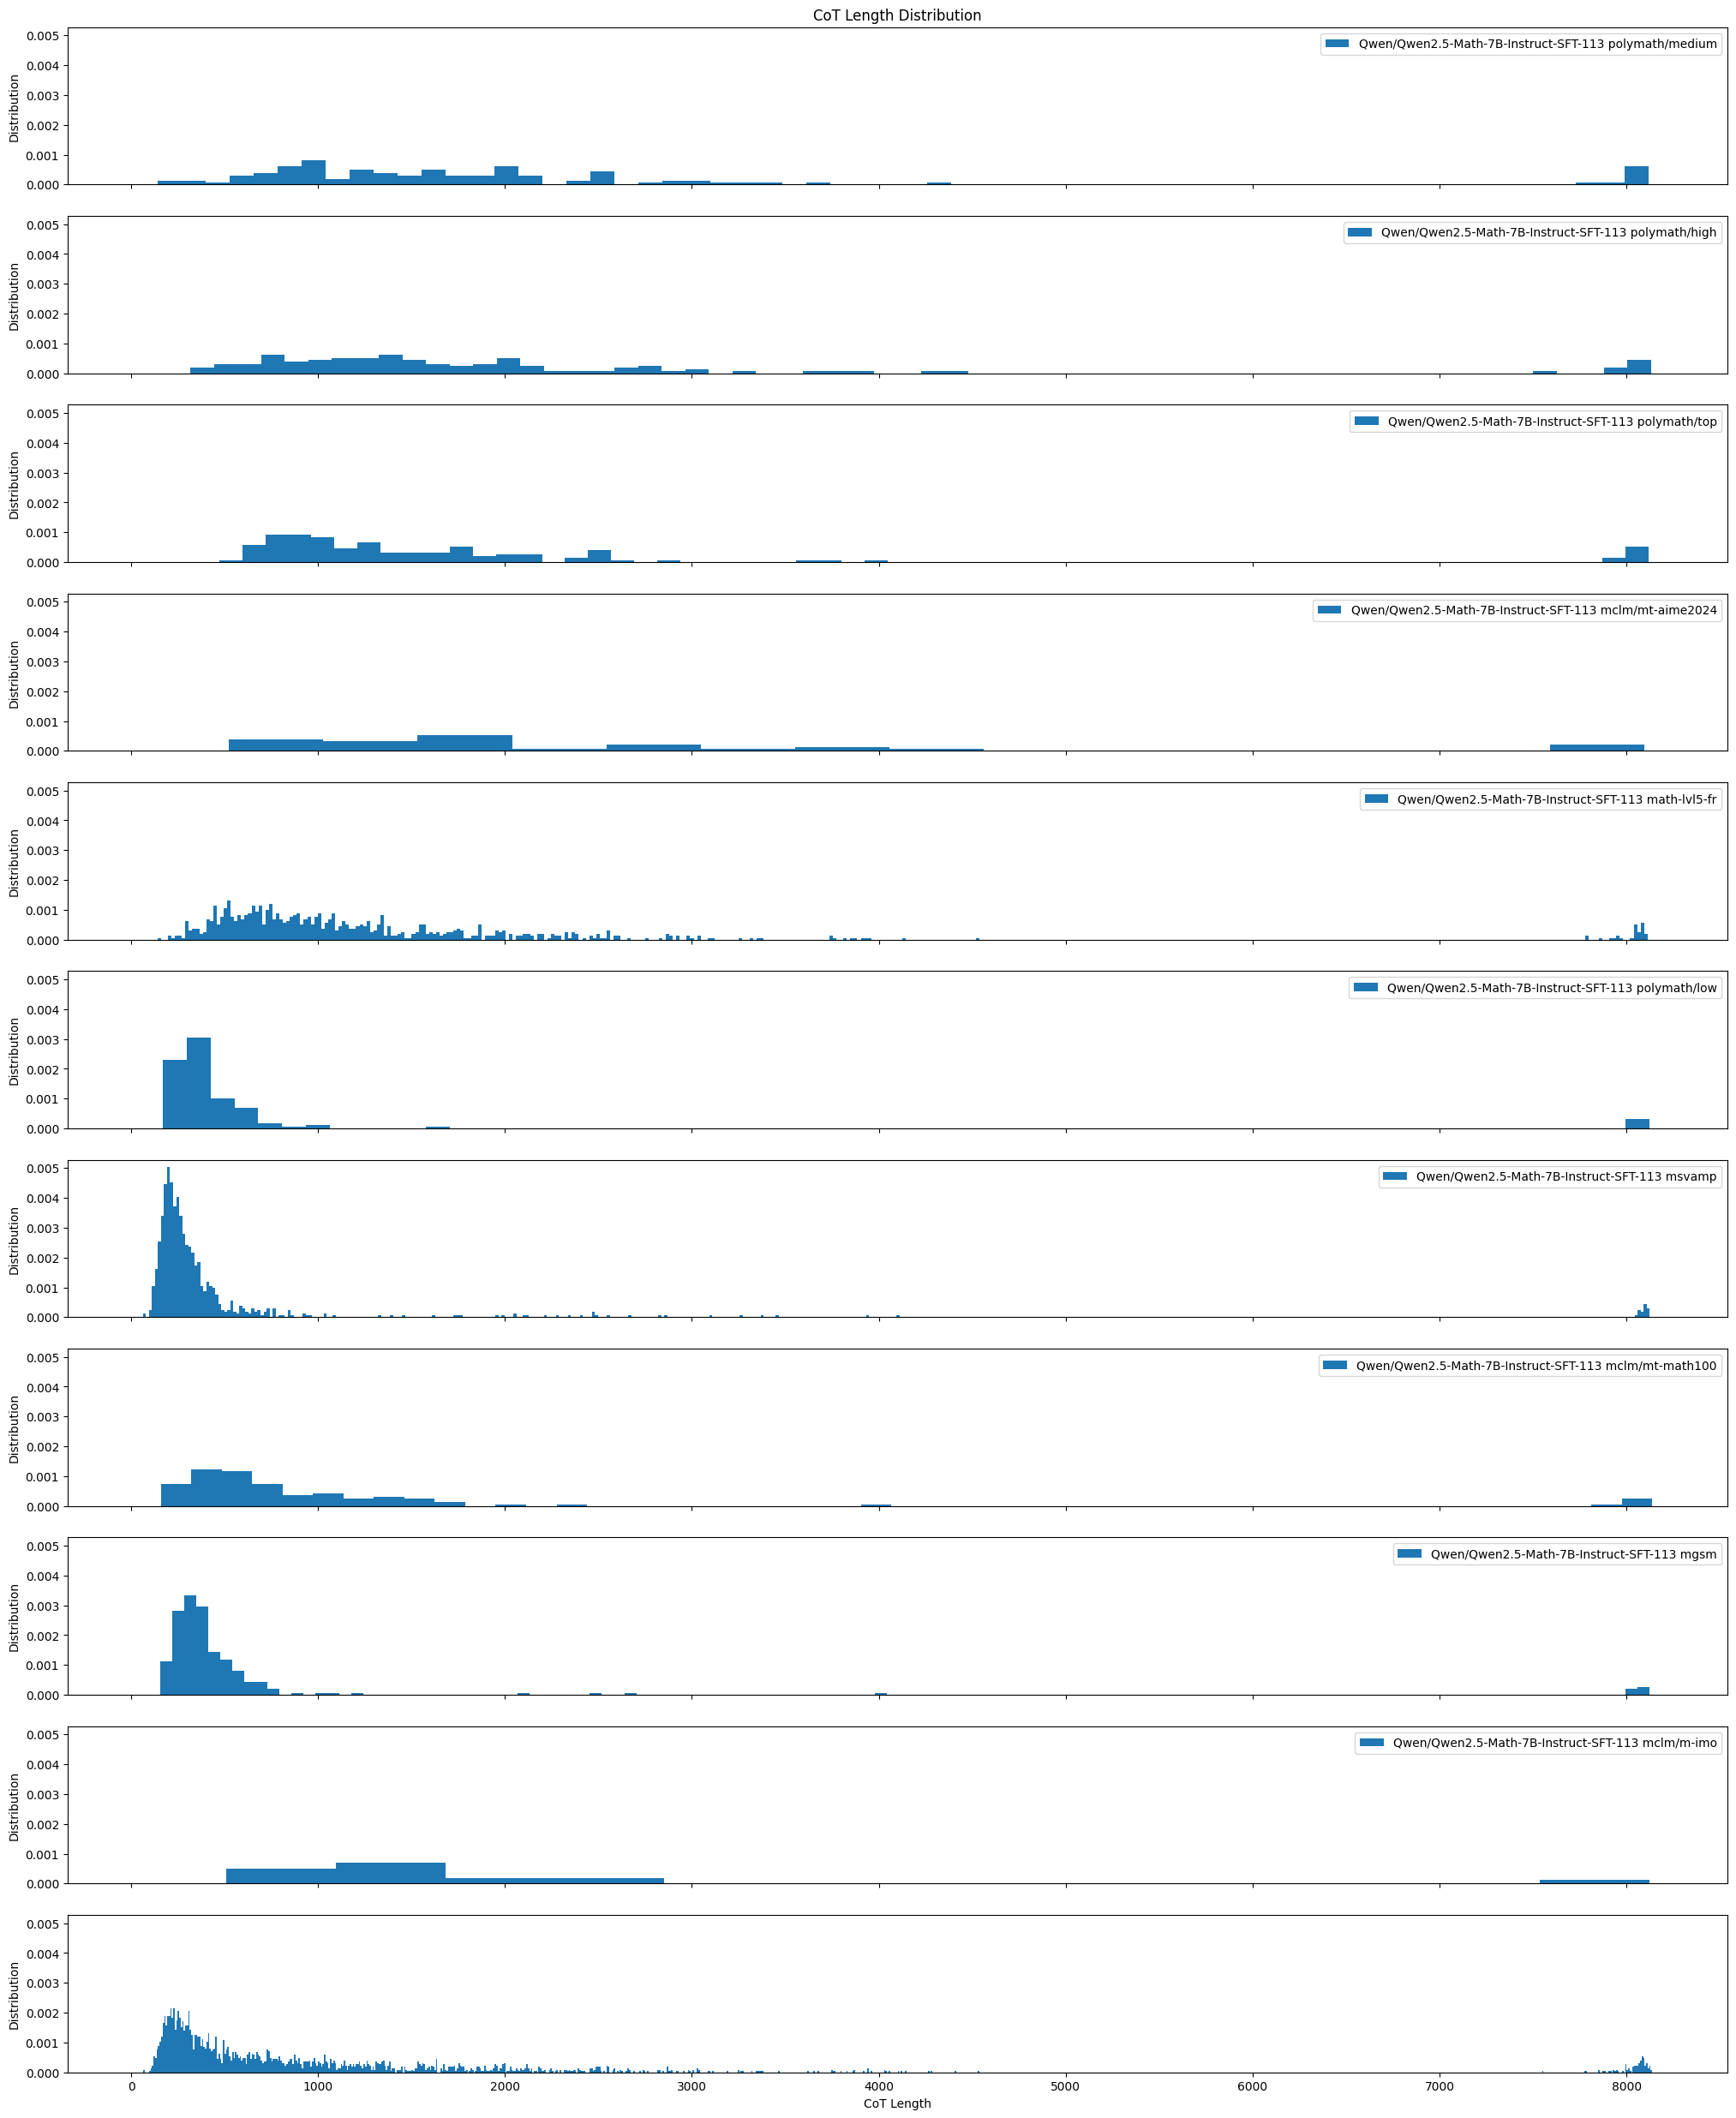

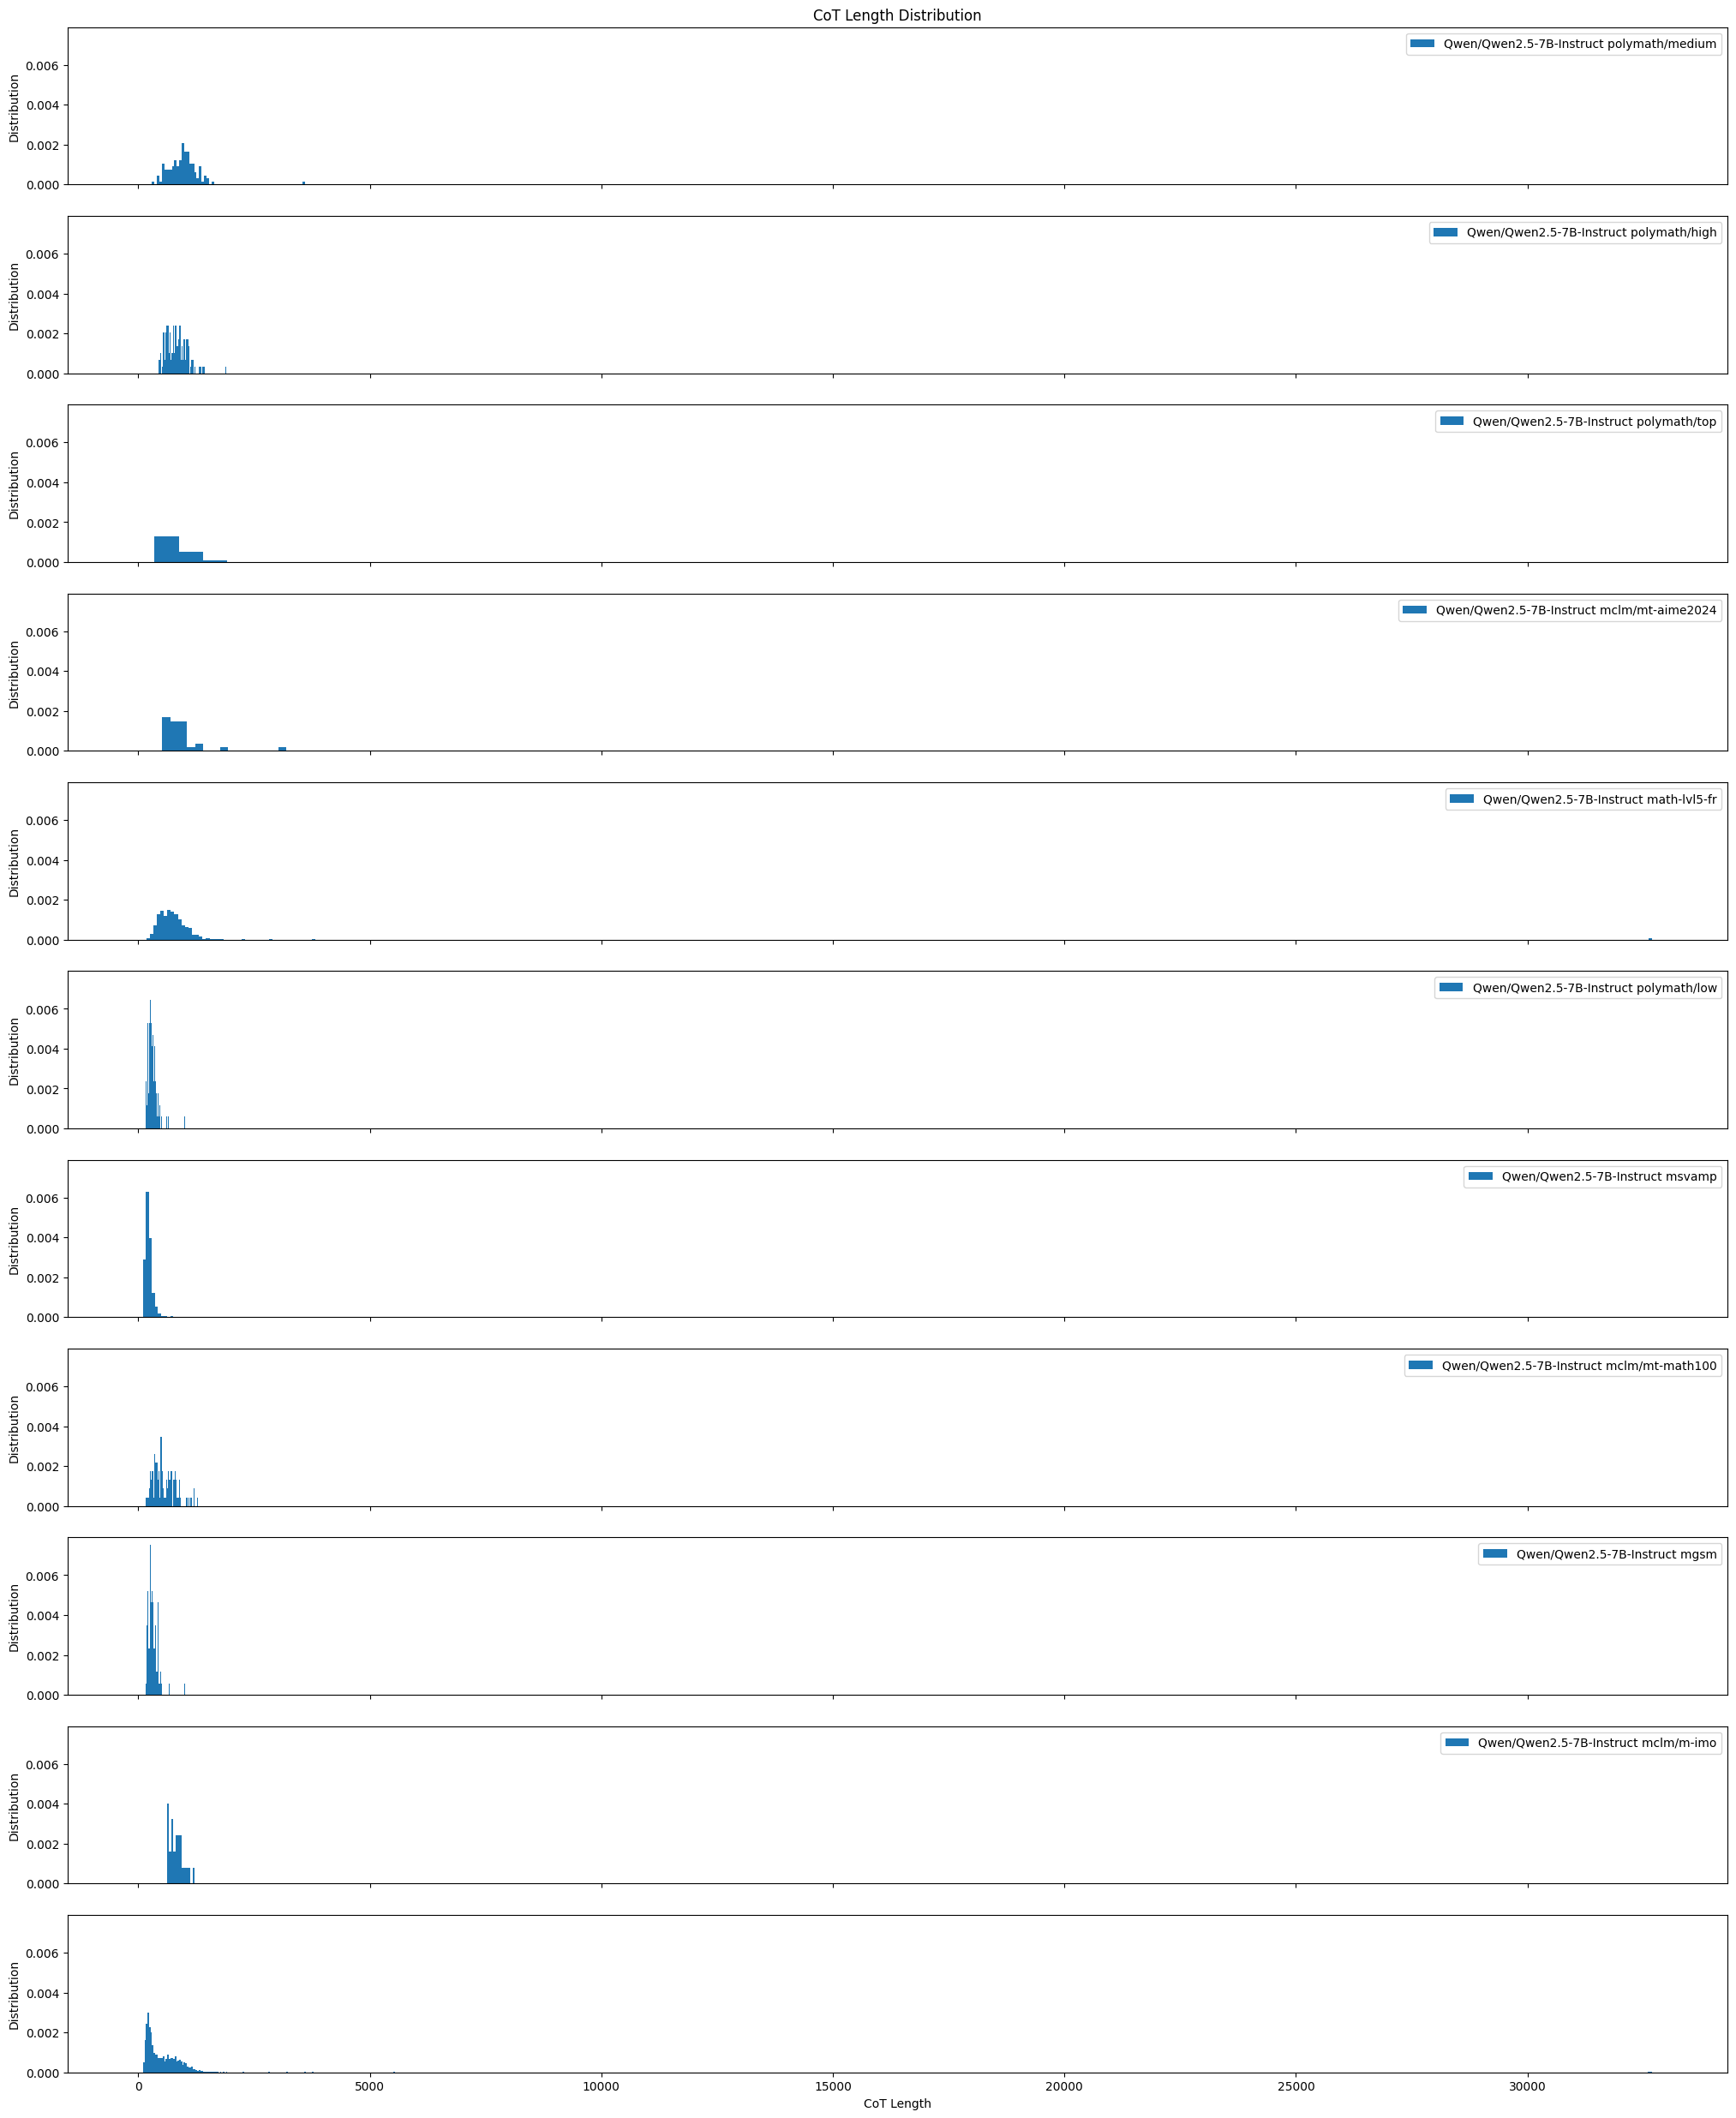

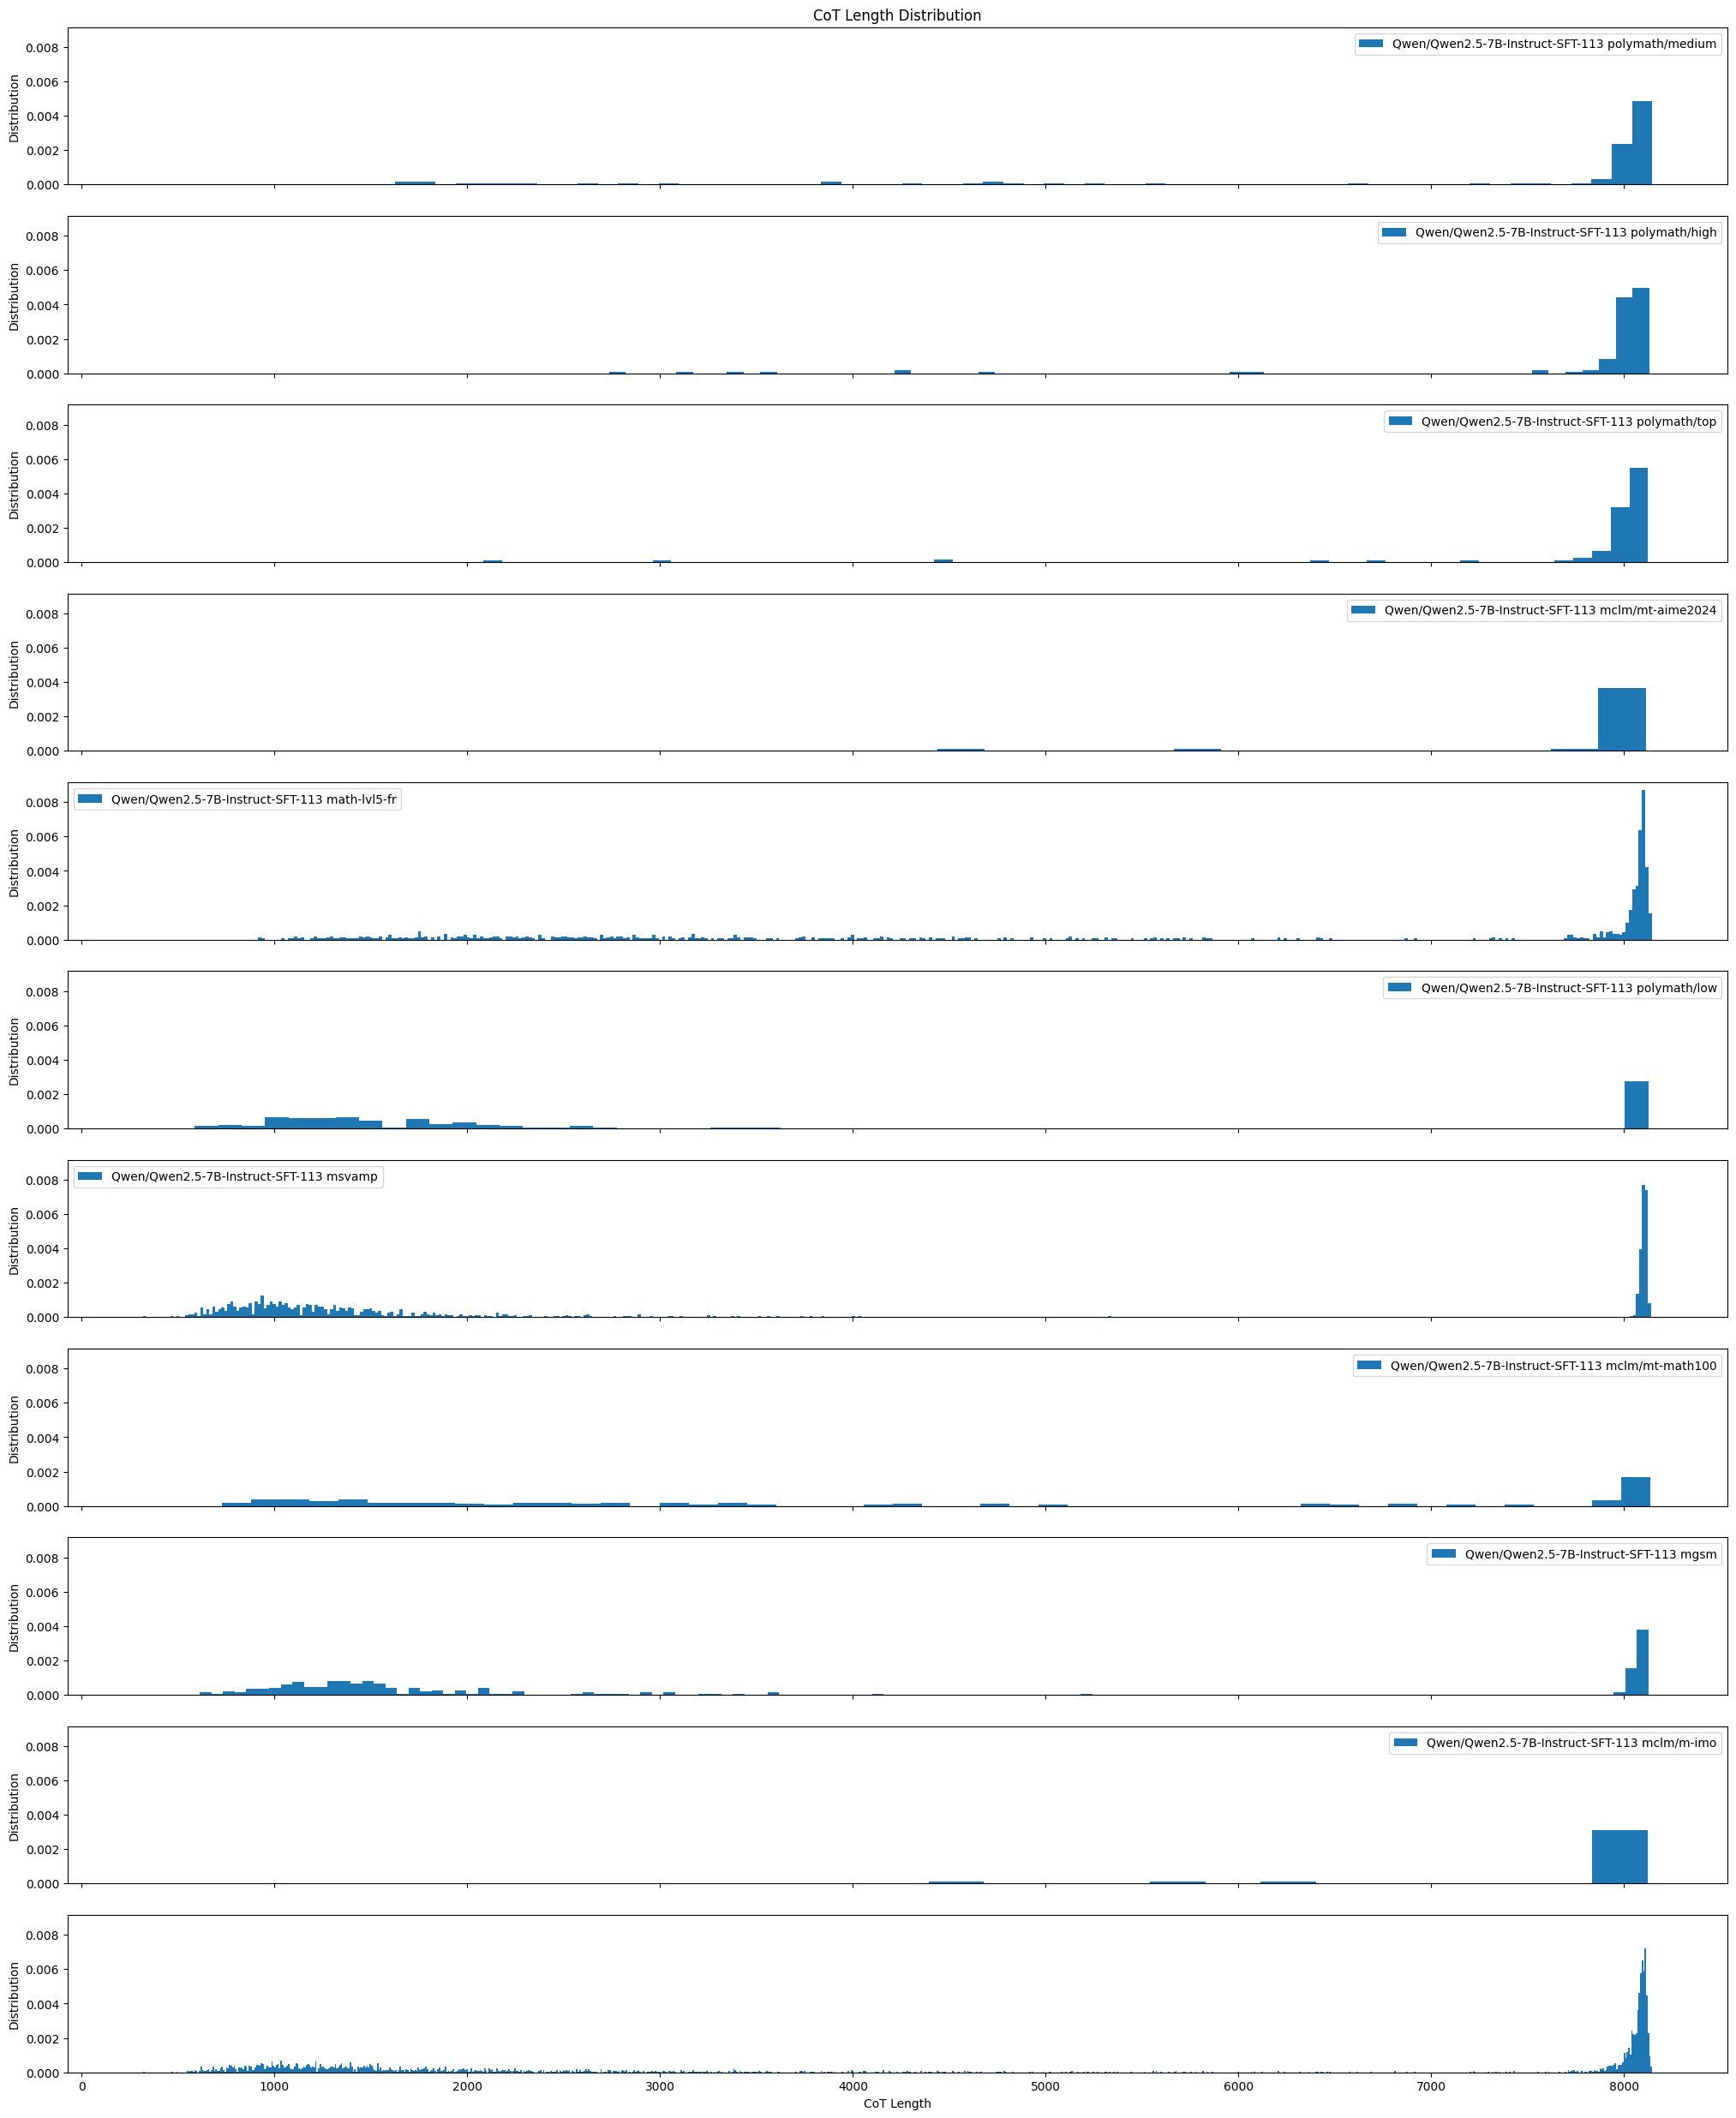

In [13]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True, sharey=True)
    axs[0].set_title("CoT Length Distribution")
    cot_lengths = []
    for i, dataset in enumerate(datasets):
        cot_lengths_dataset = []
        for sample in result["samples"][dataset]:
            cot_lengths_dataset.append(sample["cot_length"])
        cot_lengths += cot_lengths_dataset
        axs[i].hist(cot_lengths_dataset, label=model+" "+dataset, bins=len(cot_lengths_dataset)//2, density=True)
        axs[i].set_ylabel("Distribution")
        axs[i].legend()
    axs[-1].hist(cot_lengths, label=model+"average", bins=1000, density=True)
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Distribution")
    axs[-1].legend
    plt.savefig("cot_length")
    plt.show()

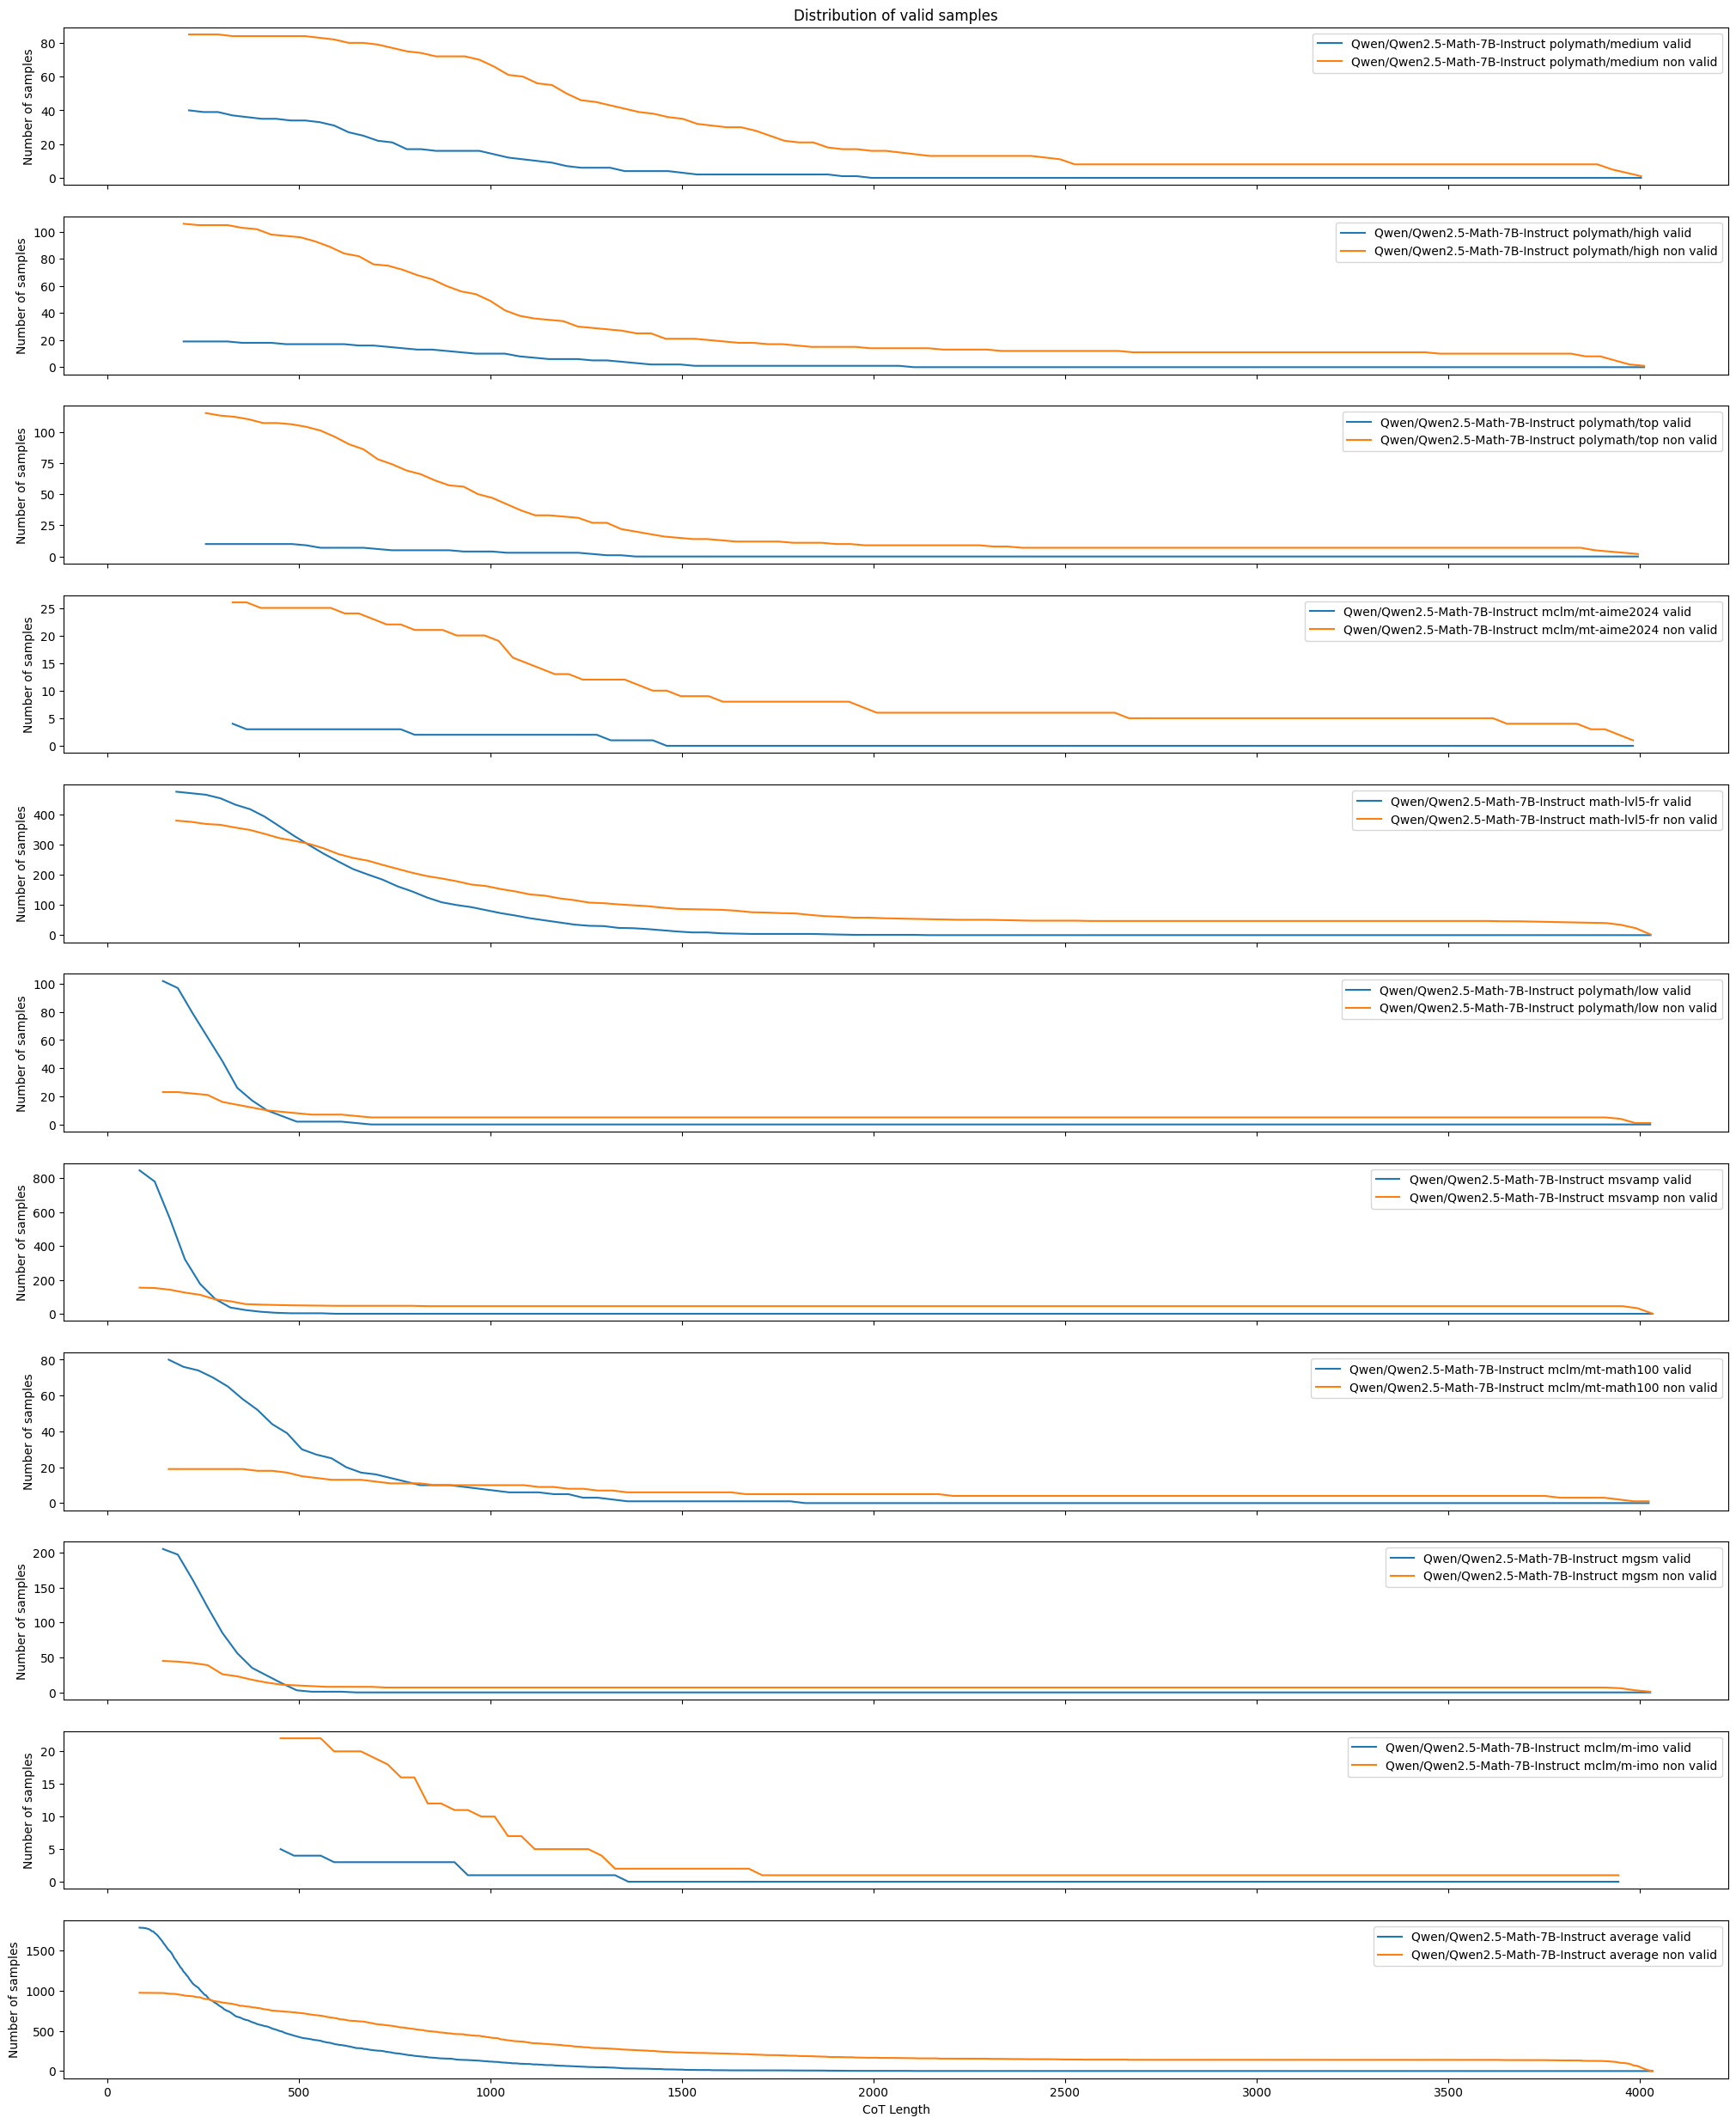

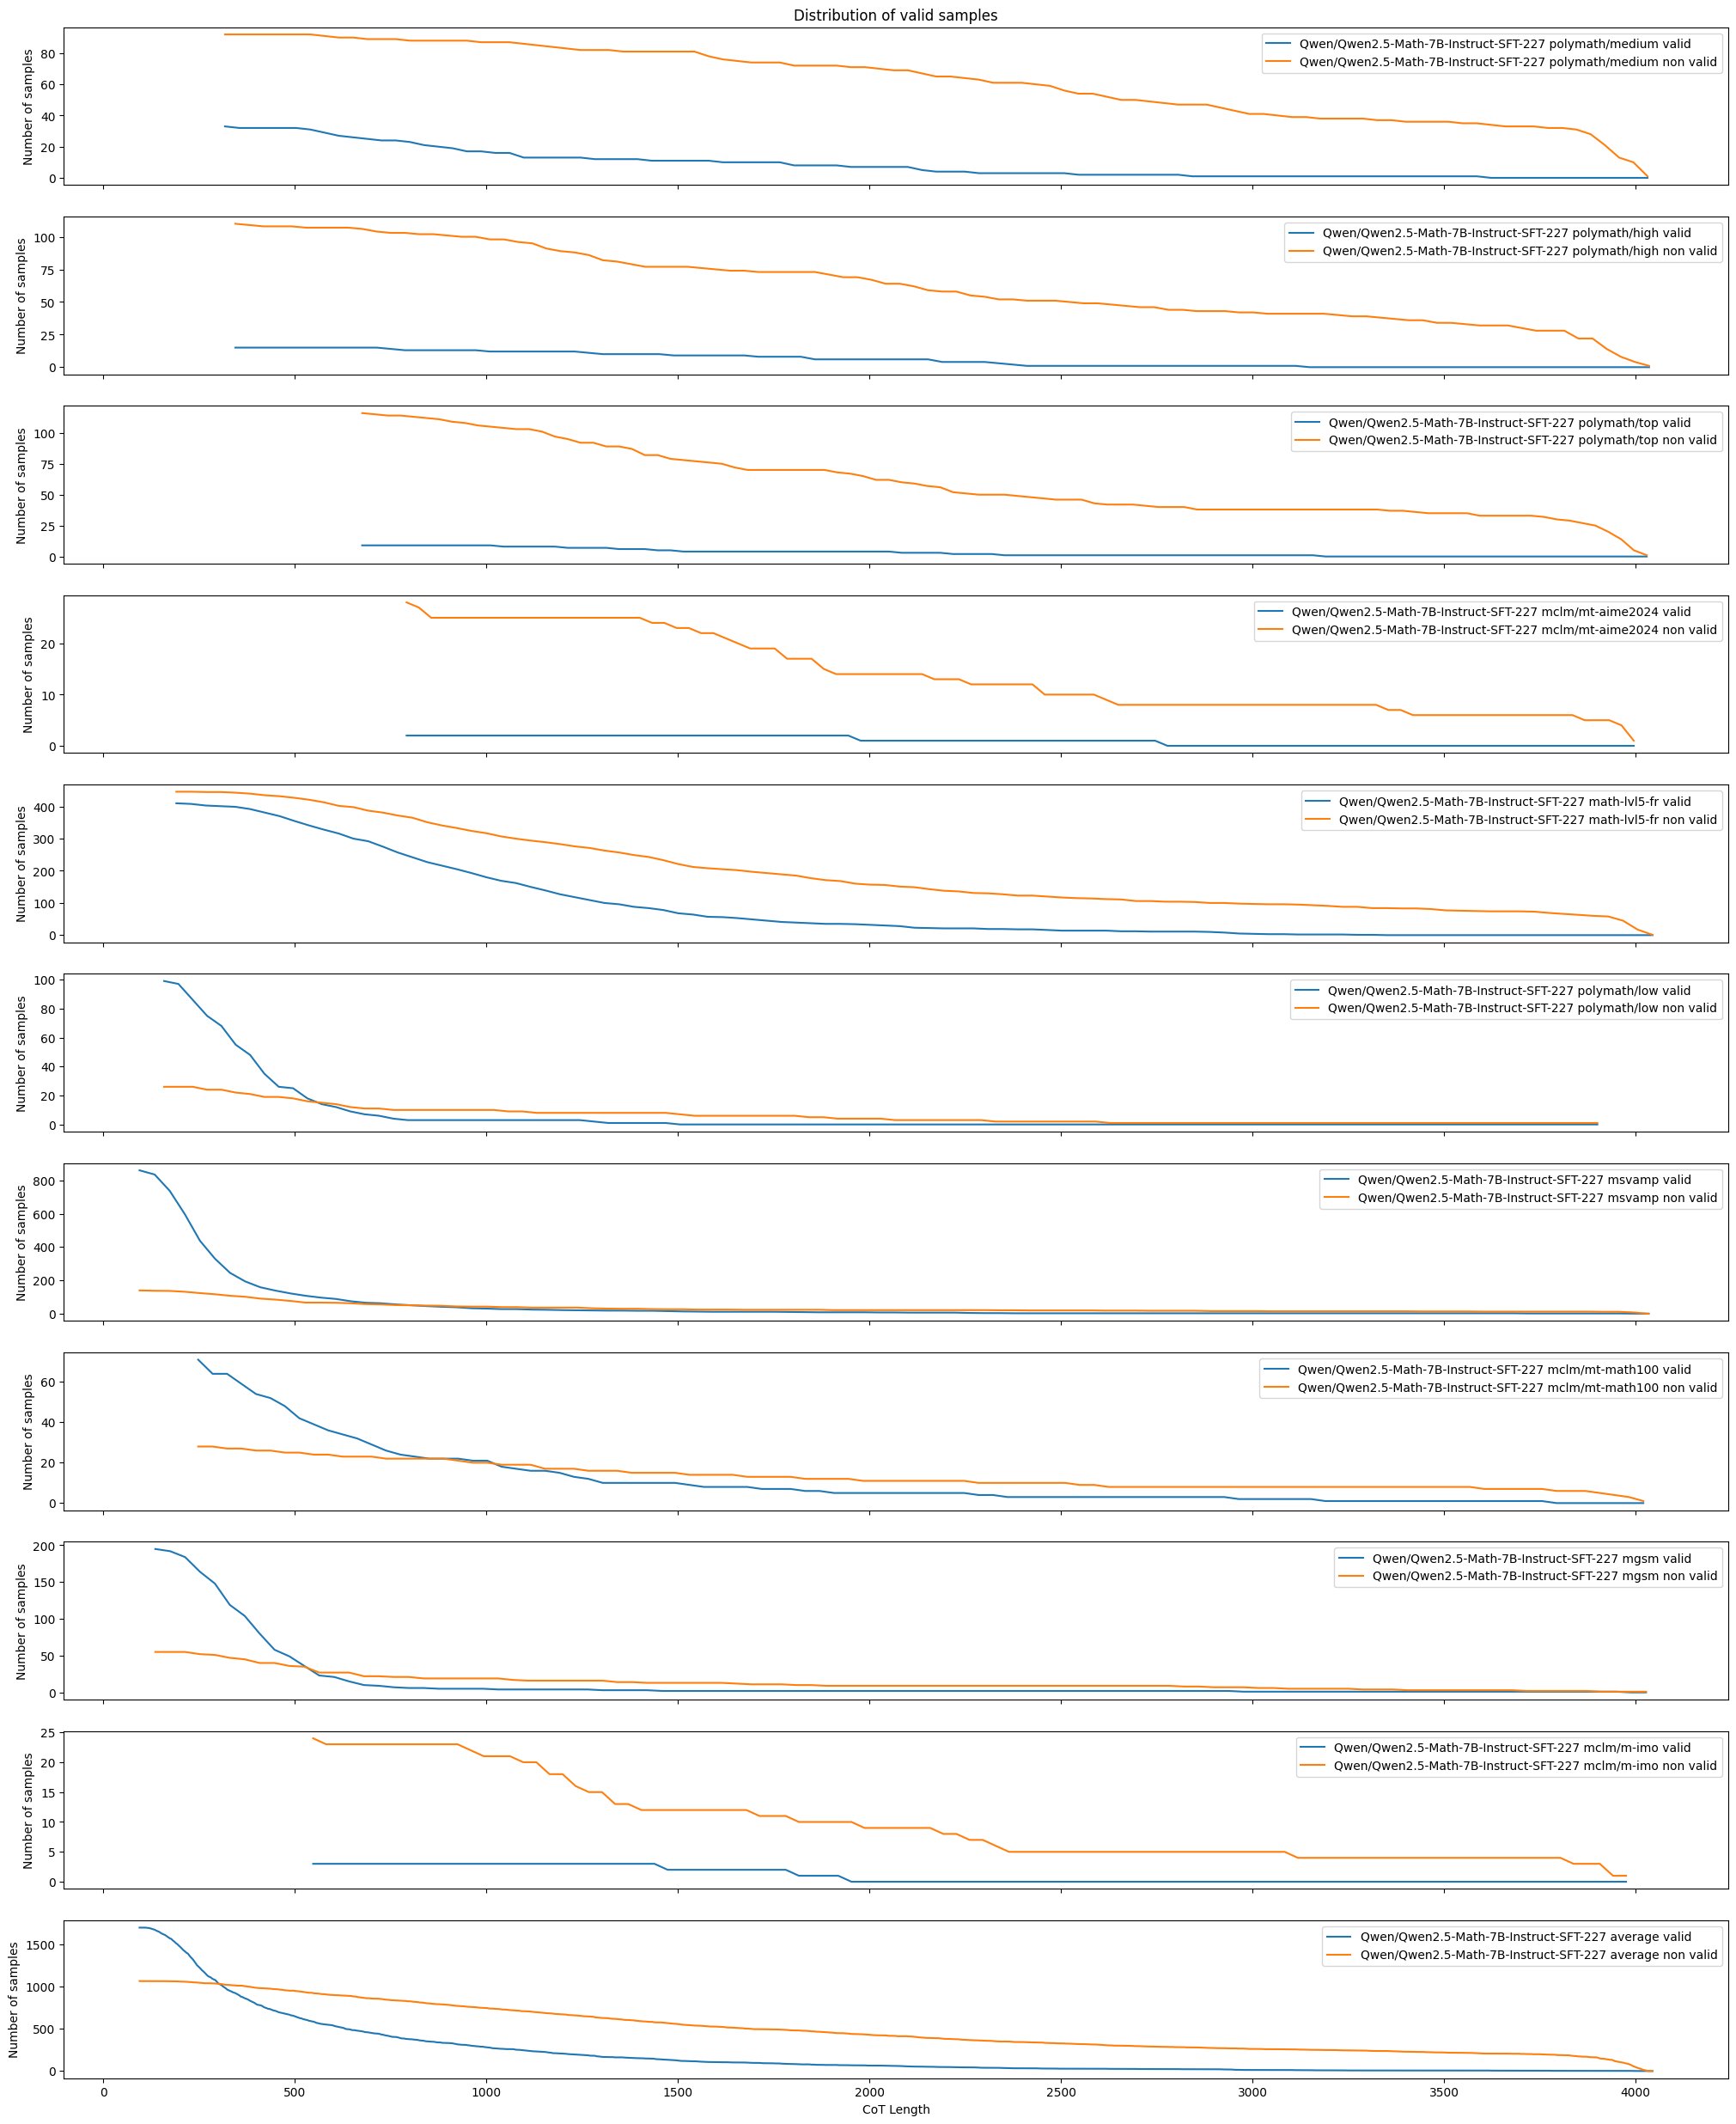

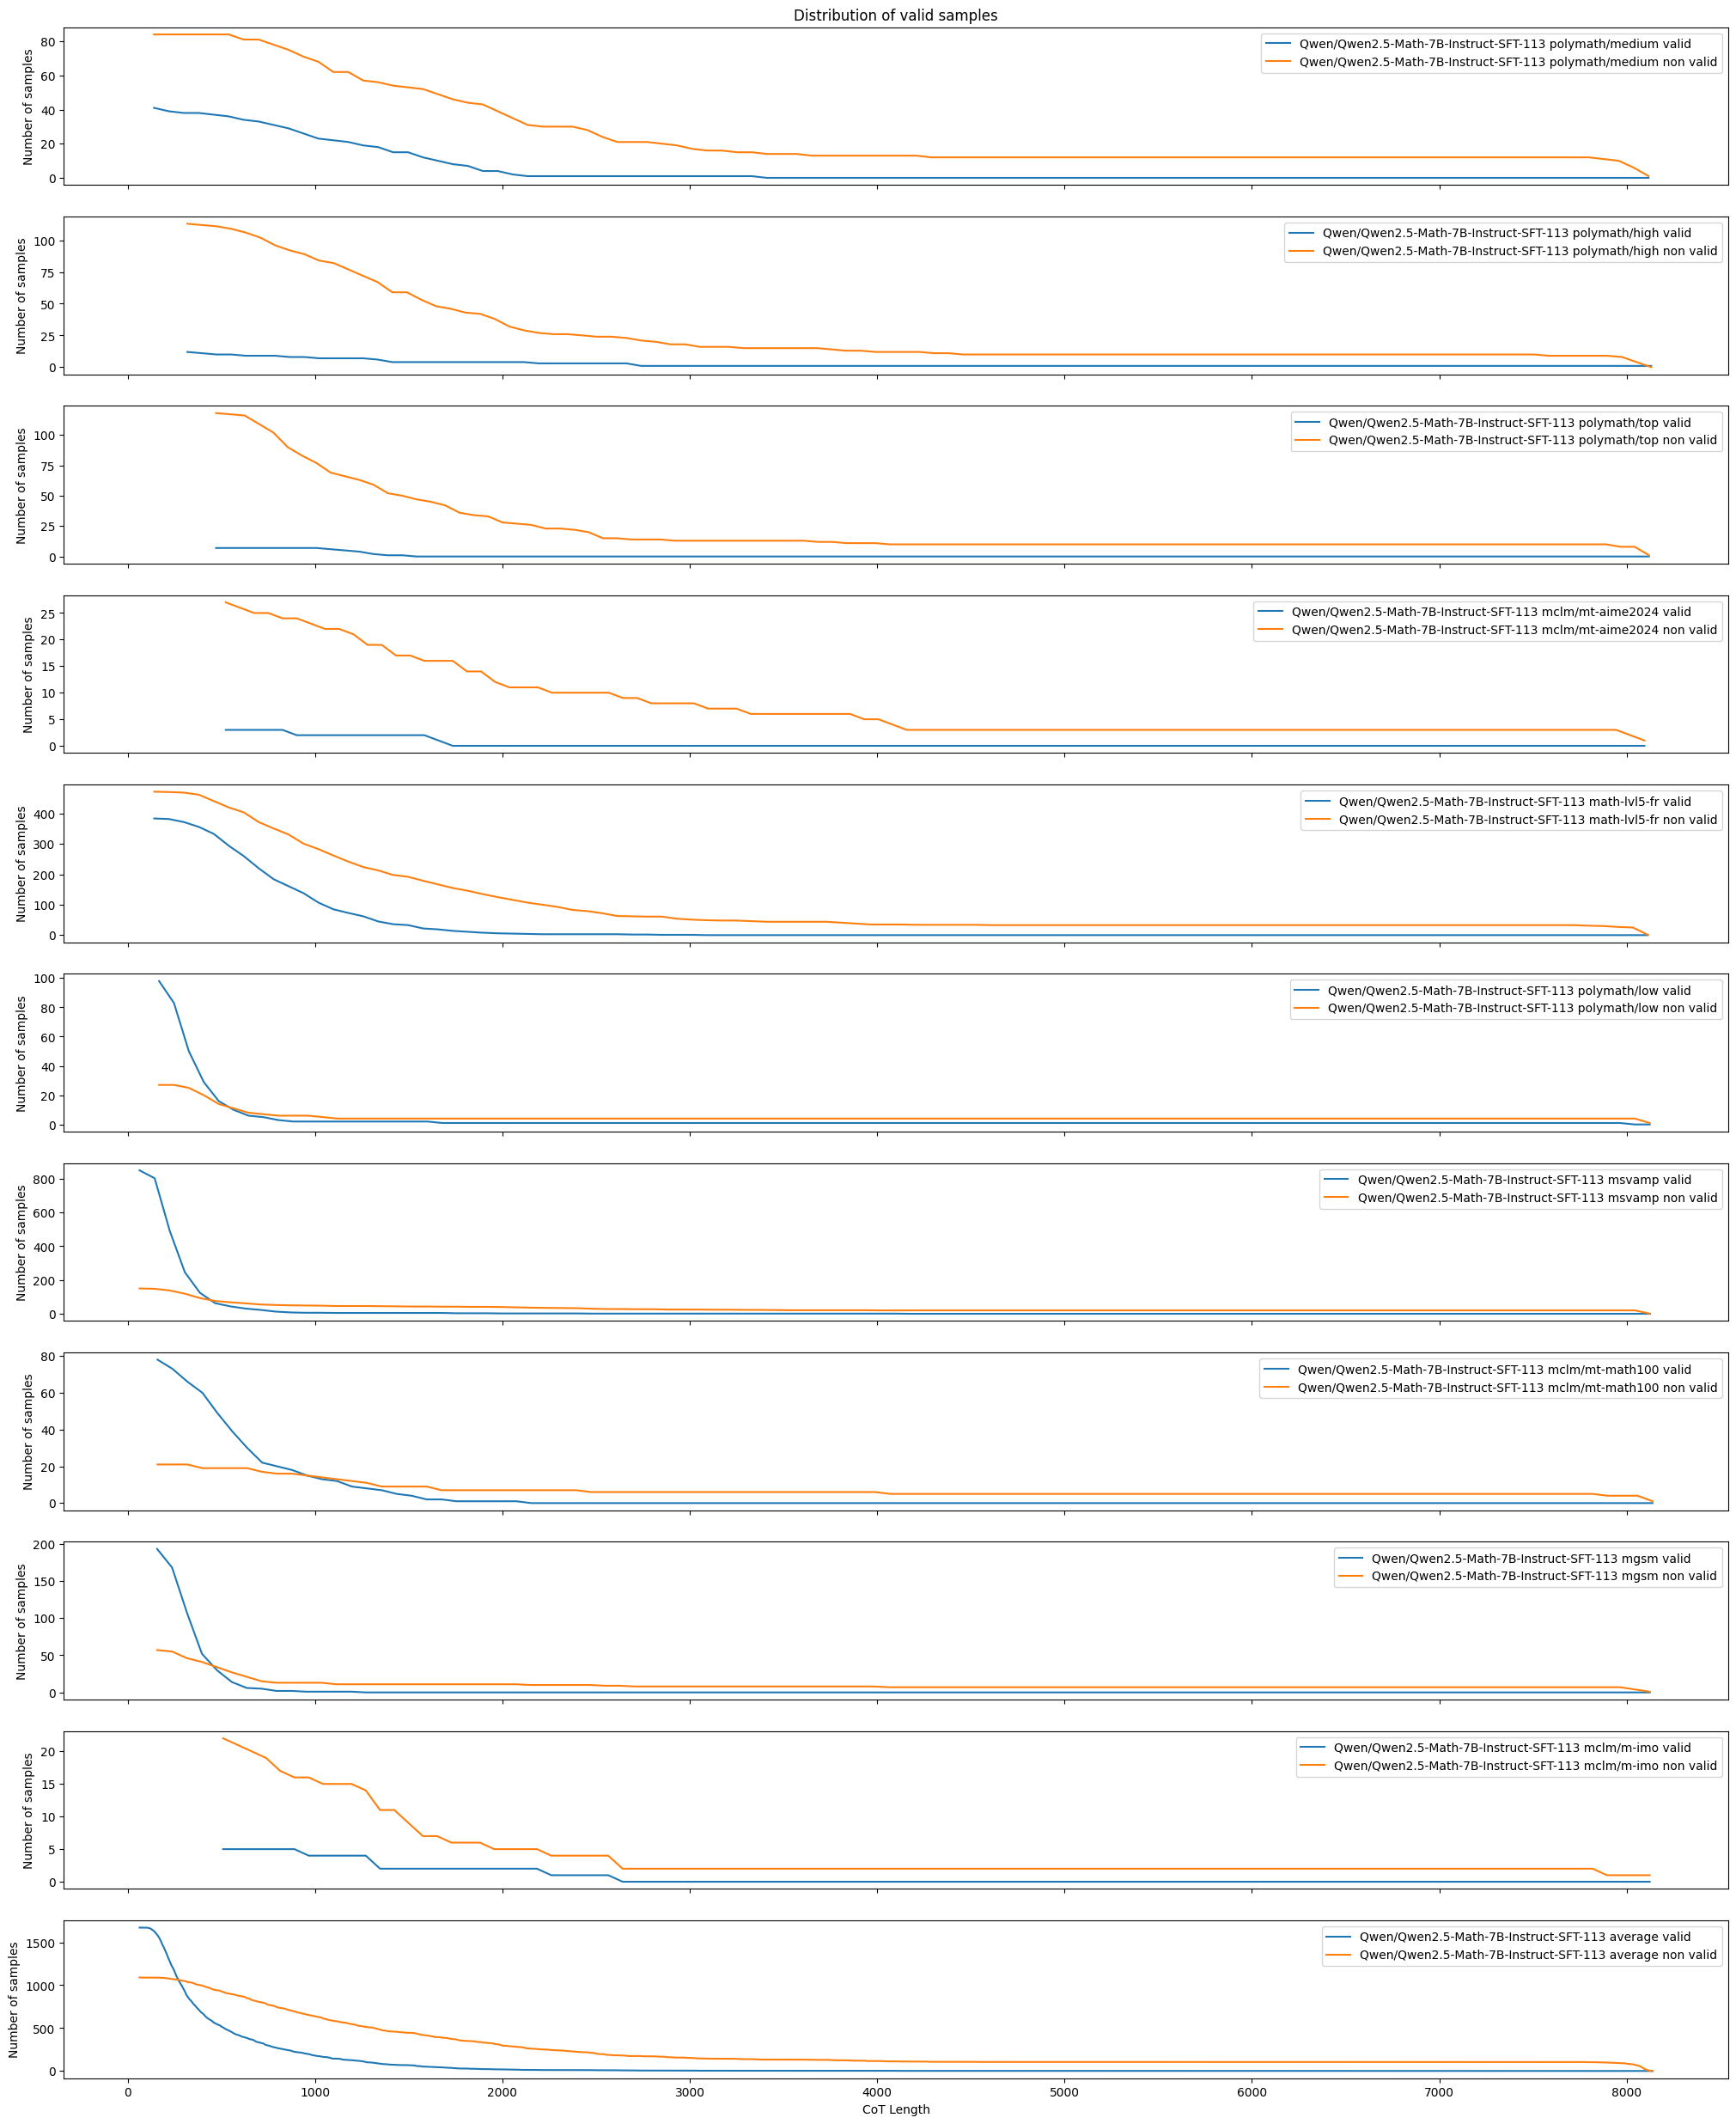

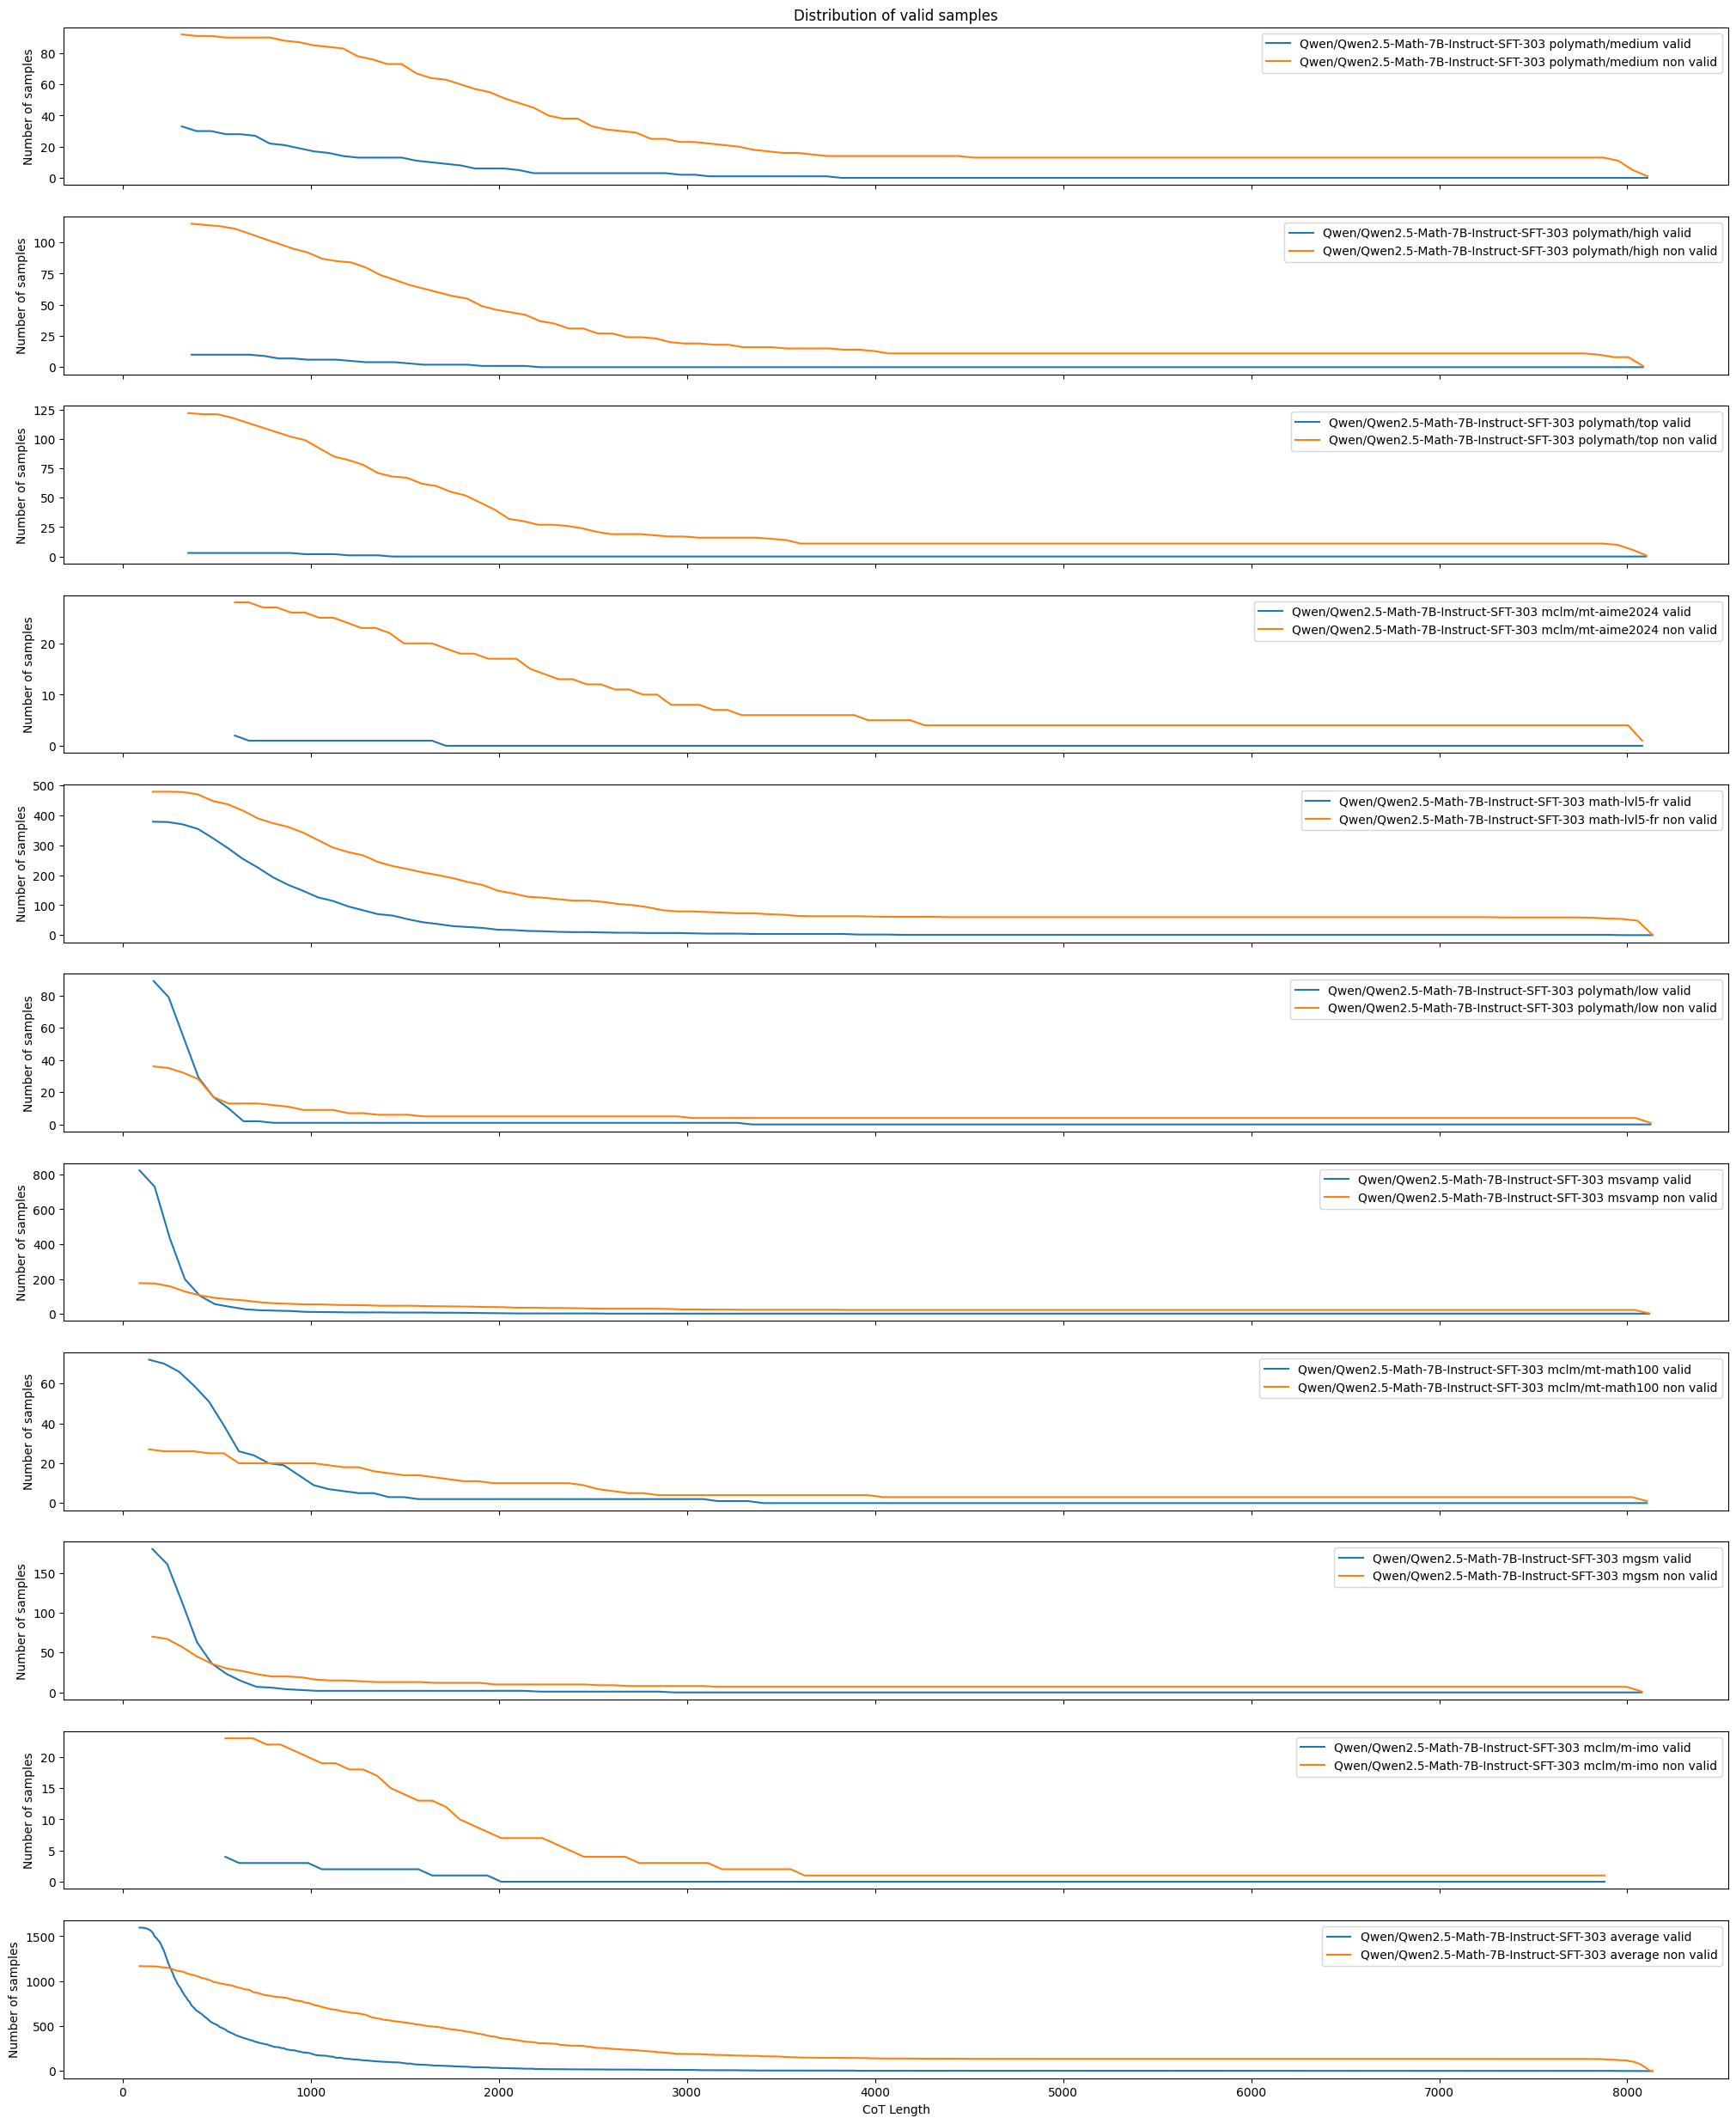

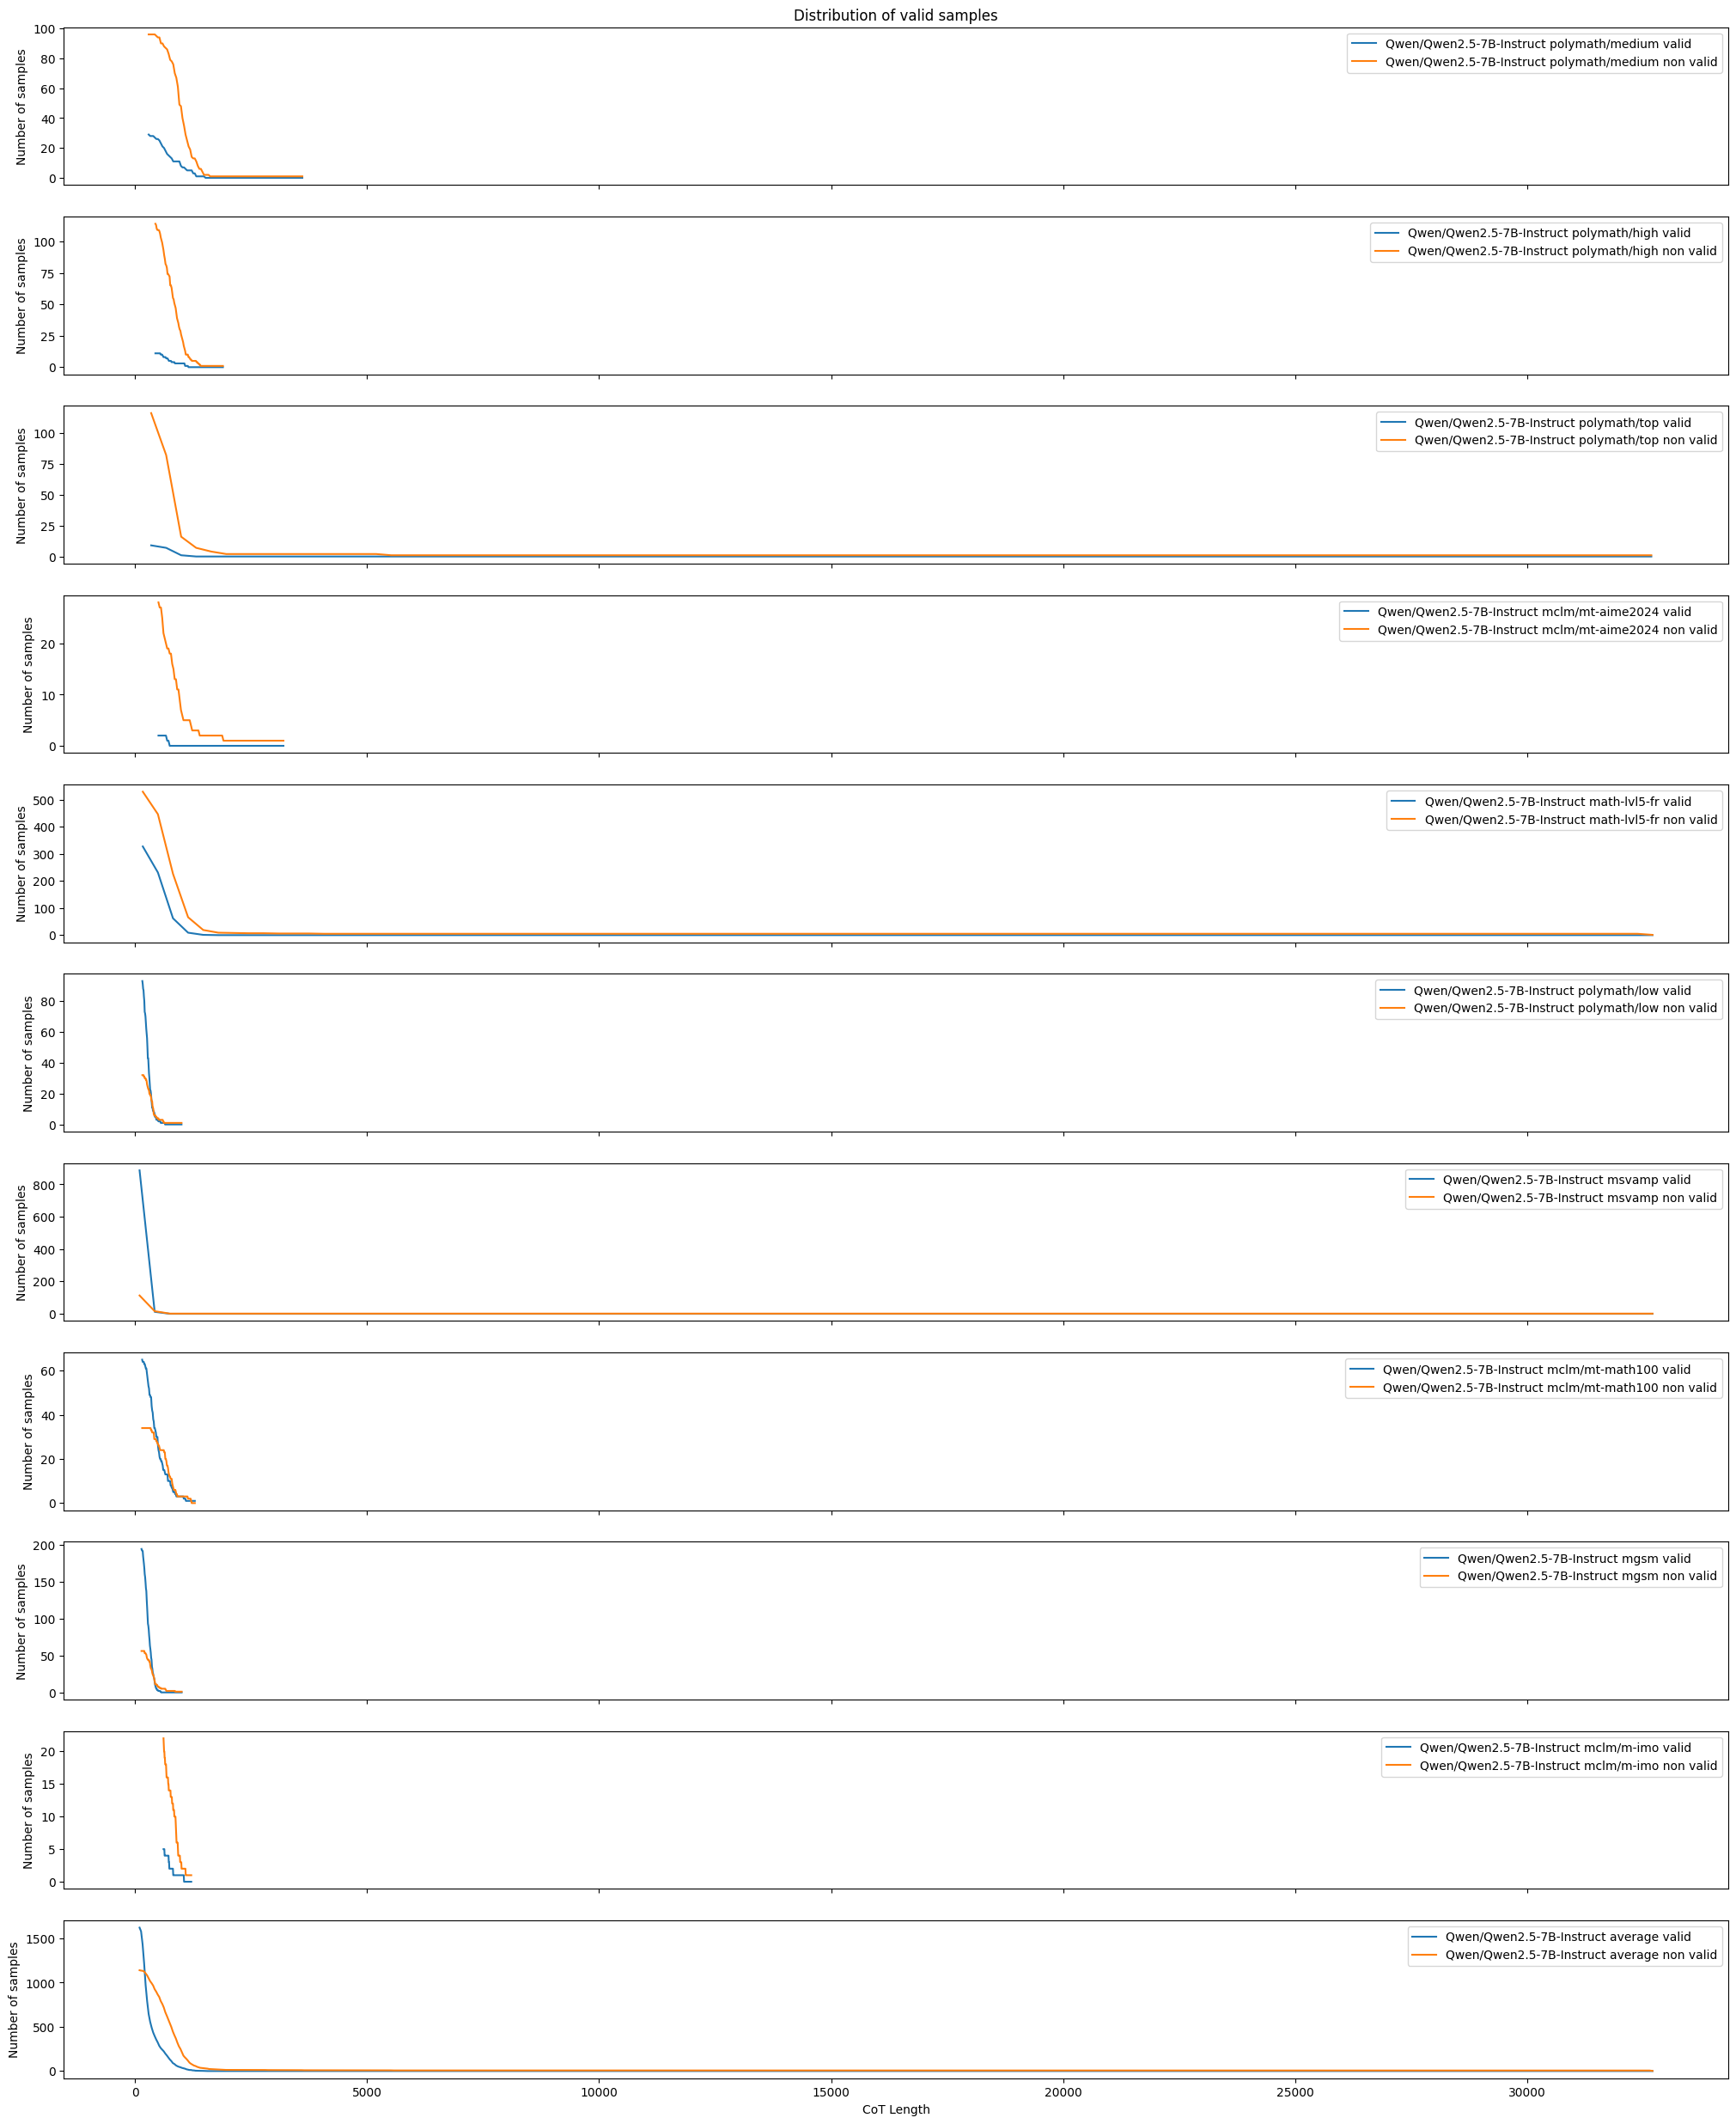

In [18]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True)
    axs[0].set_title("Distribution of valid samples")
    for i, dataset in enumerate(datasets):
        valid = []
        non_valid = []
        bins = np.histogram(
            [x["cot_length"] for x in result["samples"][dataset]],
            bins=100
        )[1]
        for x1, x2 in zip(bins, bins + [100000]):
            subset = [x["is_valid"] for x in result["samples"][dataset] if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
            valid.append(sum(subset))
            non_valid.append(len(subset)-sum(subset))
        axs[i].plot(bins, valid, label=model+" "+dataset+" valid")
        axs[i].plot(bins, non_valid, label=model+" "+dataset+" non valid")
        axs[i].set_ylabel("Number of samples")
        axs[i].legend()
        
    bins = np.histogram(
        [x["cot_length"] for dataset_result in result["samples"].values() for x in dataset_result],
        bins=1000
    )[1]
    valid = []
    non_valid = []
    for x1, x2 in zip(bins, bins + [500000]):
        subset = [x["is_valid"] for dataset_result in result["samples"].values() for x in dataset_result if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
        valid.append(sum(subset))
        non_valid.append(len(subset)-sum(subset))
    axs[-1].plot(bins, valid, label=model+" average valid")
    axs[-1].plot(bins, non_valid, label=model+" average non valid")
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Number of samples")
    axs[-1].legend()
    plt.savefig("valid.png")
    plt.show()
    